In [1]:
#!pip -q install numpy pandas matplotlib scikit-learn tqdm vector
#!pip install --upgrade gdown

import sys
import importlib
import os
import urllib.request
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
import glob
import gc
import pylhe



# Force-download the newest version of the helper file
!wget -q -O helpers.py https://raw.githubusercontent.com/andlessa/UnfoldingBSMttbar/main/helpers.py

# Import the module and force Python to clear cache and reload it
import helpers as hp
importlib.reload(hp)

# Global Plotting Configuration
plt.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 12, "axes.labelsize": 14, "axes.titlesize": 14,
    "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.linewidth": 1.0, "lines.linewidth": 2.2, "lines.markersize": 4.5,
    "legend.frameon": False, "mathtext.fontset": "cm",
})

# Dictionaries for styling
pair_colors = {"Scalar vs VLF": "#1f77b4", "Scalar vs Zprime": "#2ca02c", "VLF vs Zprime": "#d62728"}
class_colors = {"Scalar": "#1f77b4", "VLF": "#ff7f0e", "Zprime": "#2ca02c"}
pair_latex = {"Scalar vs VLF": r"Scalar vs VLF", "Scalar vs Zprime": r"Scalar vs $Z^\prime$", "VLF vs Zprime": r"VLF vs $Z^\prime$"}
class_latex = {"Scalar": r"Scalar", "VLF": r"VLF", "Zprime": r"$Z^\prime$"}
syst_styles = {0.00: ("black", "-"), 0.02: ("#1f77b4", "--"), 0.05: ("#ff7f0e", "-."), 0.10: ("#d62728", ":")}
eps_styles = {
    0.0: ('-', 'D'),
    0.02: ("-.", "o"),
    0.05: ("--", "s"),
    0.10: (":", "^")
}

In [5]:
import sys
import os
import glob
import importlib.util
import numpy as np
import pandas as pd
import pylhe
from tqdm import tqdm

# --- LHAPDF Path Setup ---
# Replace with your actual LHAPDF installation path if different
sys.path.append("/home/vinicius/MG5/HEPTools/lhapdf6_py3/lib/python3.14/dist-packages")
import lhapdf

# ==========================================
# 1. CONFIGURATION & MODEL REGISTRY SETUP
# ==========================================
E_BEAM = 6500.0    # Beam energy in GeV (e.g., 6500 for 13 TeV LHC)
PDF_NAME = 244600  # Must match the PDF set used in your MG5 event generation

# Fixed Renormalization & Factorization Scale 
MU_F  = 91.188     # Factorization scale in GeV (used ONLY for LHAPDF parton densities)
MU_R  = 91.188    # Renormalization scale in GeV (used for LHAPDF alpha_s)
MU_R2 = MU_R**2    # Renormalization scale squared in GeV^2 (used for MadLoop virtuals)   # Scale squared in GeV^2 (used for MadLoop virtuals)

# Define absolute root paths for all 3 model hypotheses
MODEL_ROOTS = {
    "VLF":    os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/UV_BSM/MatrixElements/SubProcesses"),
    "Scalar": os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/SMS_1_loop/MatrixElements/SubProcesses"),
    "Zprime": os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/z_prime/MatrixElements/SubProcesses")
}

# Define production channels (using P1_ indexing for Zprime as confirmed earlier)
MODEL_CHANNELS = {
    "VLF":    ["P0_uux_ttx", "P2_gg_ttx"],
    "Scalar": ["P0_uux_ttx", "P2_gg_ttx"],
    "Zprime": [
        "P1_uux_ttx", 
        "P1_ddx_ttx", 
        "P1_gg_ttx"
    ]
}

# Map MadGraph directory prefixes to their corresponding PDG quark IDs for PDF lookup
PDG_MAP = {
    "uux": 2,  # Up
    "ddx": 1,  # Down
    "ssx": 3,  # Strange
    "ccx": 4,  # Charm
    "bbx": 5   # Bottom
}

# ==========================================
# 2. UNIVERSAL LIBRARY LOADER & INITIALIZER
# ==========================================
def init_model_card(module, subproc_path, module_label):
    """Dynamically detects and calls the correct Fortran initialization routine."""
    card_path = os.path.abspath(os.path.join(subproc_path, "..", "..", "Cards", "param_card.dat"))
    if not os.path.exists(card_path):
        raise FileNotFoundError(f"[{module_label}] Could not find parameter card at: {card_path}")
    
    original_cwd = os.getcwd()
    try:
        os.chdir(subproc_path)
        mod_attrs = dir(module)
        lo_init = [a for a in mod_attrs if a.endswith('initialisemodel')]
        nlo_init = [a for a in mod_attrs if 'initialise' in a and not a.endswith('initialisemodel')]
        
        if lo_init:
            getattr(module, lo_init[0])(card_path)
        elif nlo_init:
            getattr(module, nlo_init[0])(card_path)
        else:
            raise AttributeError(f"[{module_label}] No valid initialization subroutine found!")
    finally:
        os.chdir(original_cwd)

def load_all_models(roots_dict, channels_dict):
    """Loads and compiles all matrix_*.so libraries into a unified dictionary registry."""
    registry = {}
    print("Loading Matrix Element Libraries...\n" + "="*50)
    for model_name, root_dir in roots_dict.items():
        print(f" -> Loading Model: [{model_name}]")
        registry[model_name] = {}
        for channel in channels_dict[model_name]:
            subproc_path = os.path.join(root_dir, channel)
            if subproc_path not in sys.path:
                sys.path.append(subproc_path)
            
            so_files = glob.glob(os.path.join(subproc_path, f"*matrix_{model_name}*.so")) or \
                       glob.glob(os.path.join(subproc_path, "*matrix*.so"))
            if not so_files:
                raise FileNotFoundError(f"No compiled .so library found in {subproc_path}")
            
            so_path = so_files[0]
            lib_name = os.path.basename(so_path).split(".")[0]  # Strip architecture tags
            
            spec = importlib.util.spec_from_file_location(lib_name, so_path)
            mod = importlib.util.module_from_spec(spec)
            sys.modules[lib_name] = mod
            spec.loader.exec_module(mod)
            
            init_model_card(mod, subproc_path, f"{model_name} | {channel}")
            registry[model_name][channel] = {
                "module": mod,
                "path": subproc_path
            }
            print(f"    [✓] {channel}")
    print("="*50 + "\n")
    return registry

# Initialize global model registry
models = load_all_models(MODEL_ROOTS, MODEL_CHANNELS)

def eval_full_me(module_dict, p_fortran, alphas, scale2, nhel=-1):
    """
    Evaluates matrix elements and returns them decomposed by component.
    Returns a dictionary: {'born': val, 'finite': val, 'me_total': val}
    """
    mod = module_dict["module"]
    subproc_path = module_dict["path"]
    mod_attrs = dir(mod)
    
    lo_eval = [a for a in mod_attrs if a.endswith('get_value')]
    nlo_eval = [a for a in mod_attrs if a.endswith('get_me')]
    
    original_cwd = os.getcwd()
    try:
        os.chdir(subproc_path)
        
        # --- CASE 1: LEADING ORDER (Tree-Level, e.g., Zprime) ---
        if lo_eval:
            val = getattr(mod, lo_eval[0])(p_fortran, alphas, nhel)
            val_list = [float(x) for x in np.ravel(val)]
            me_born = val_list[0] if len(val_list) > 0 else 0.0
            return {"born": me_born, "finite": 0.0, "me_total": me_born}
            
        # --- CASE 2: NEXT-TO-LEADING ORDER / LOOP (e.g., VLF, Scalar) ---
        elif nlo_eval:
            res, _ = getattr(mod, nlo_eval[0])(p_fortran, alphas, scale2, nhel)
            res_list = [float(x) for x in np.ravel(res)]
            
            if len(res_list) == 4:
                # Array structure: [Born, Finite, 1eps, 2eps]
                born_val   = res_list[0]
                finite_val = res_list[1]
                return {
                    "born": born_val, 
                    "finite": finite_val, 
                    "me_total": born_val + finite_val
                }
            else:
                # Unpatched Wrapper: res_list[0] is Finite term
                finite_val = res_list[0] if len(res_list) > 0 else 0.0
                return {
                    "born": 0.0, 
                    "finite": finite_val, 
                    "me_total": finite_val
                }
                
        else:
            raise AttributeError("Module does not define get_value or get_me!")
            
    finally:
        os.chdir(original_cwd)

Loading Matrix Element Libraries...
 -> Loading Model: [VLF]
    [✓] P0_uux_ttx
    [✓] P2_gg_ttx
 -> Loading Model: [Scalar]
    [✓] P0_uux_ttx
    [✓] P2_gg_ttx
 -> Loading Model: [Zprime]
    [✓] P1_uux_ttx
    [✓] P1_ddx_ttx
    [✓] P1_gg_ttx



In [4]:
import os
import numpy as np
import pandas as pd
import lhapdf
import pylhe
from tqdm import tqdm

def invert_momenta(p):
    new_p = [[0] * len(p) for _ in range(len(p[0]))]
    for i, onep in enumerate(p):
        for j, x in enumerate(onep):
            new_p[j][i] = x
    return new_p


# ==========================================
# 1. ENHANCED MATRIX ELEMENT EVALUATOR
# ==========================================



# ==========================================
# 2. DECOUPLED MATRIX ELEMENT & FLUX COMPUTATION
# ==========================================
def compute_matrix_elements(lhe_path, output_csv_path=None):
    print(f"Processing LHE file: {lhe_path}")
    print(f"Initializing LHAPDF with set {PDF_NAME}...")
    
    if isinstance(PDF_NAME, int):
        pdf = lhapdf.mkPDF(PDF_NAME)
    else:
        pdf = lhapdf.mkPDF(str(PDF_NAME), 0)
    
    try:
        total_events = pylhe.read_num_events(lhe_path)
    except Exception:
        total_events = None

    events = pylhe.read_lhe_with_attributes(lhe_path)
    results = []
    
    for idx, event in enumerate(tqdm(events, total=total_events, desc="Computing Raw MEs & Fluxes")):
        outgoing = [p for p in event.particles if p.status == 1]
        if len(outgoing) != 2:
            continue
            
        # Ensure strict ordering: [Top (6), Anti-Top (-6)]
        outgoing = sorted(outgoing, key=lambda x: x.id, reverse=True)
        t, tbar = outgoing[0], outgoing[1]
        
        # --- Kinematic Reconstruction ---
        E_tt  = t.e + tbar.e
        pz_tt = t.pz + tbar.pz
        x1 = (E_tt + pz_tt) / (2.0 * E_BEAM)
        x2 = (E_tt - pz_tt) / (2.0 * E_BEAM)
        
        if not (0 < x1 < 1.0 and 0 < x2 < 1.0):
            continue
            
        px_tt = t.px + tbar.px
        py_tt = t.py + tbar.py
        s_hat = E_tt**2 - px_tt**2 - py_tt**2 - pz_tt**2
        
        # --- Evaluate Scales and PDF Fluxes ---
        alphas = pdf.alphasQ(MU_R)
        
        # 1. Gluon Luminosity: g(x1) * g(x2)
        w_gg = (pdf.xfxQ(21, x1, MU_F) / x1) * (pdf.xfxQ(21, x2, MU_F) / x2)
        
        # 2. Flavor-Specific Quark Luminosities: q(x1)qbar(x2) + qbar(x1)q(x2)
        pdf_fluxes = {"w_gg": w_gg}
        for q_name, q_id in PDG_MAP.items():
            fq_1    = pdf.xfxQ(q_id, x1, MU_F) / x1
            fqbar_2 = pdf.xfxQ(-q_id, x2, MU_F) / x2
            fqbar_1 = pdf.xfxQ(-q_id, x1, MU_F) / x1
            fq_2    = pdf.xfxQ(q_id, x2, MU_F) / x2
            
            pdf_fluxes[f"w_{q_name}"] = (fq_1 * fqbar_2) + (fqbar_1 * fq_2)
        
        # --- Format 4-momenta for Fortran ---
        p1 = [x1 * E_BEAM, 0.0, 0.0,  x1 * E_BEAM]
        p2 = [x2 * E_BEAM, 0.0, 0.0, -x2 * E_BEAM]
        p_list = [p1, p2, [t.e, t.px, t.py, t.pz], [tbar.e, tbar.px, tbar.py, tbar.pz]]
        P_fortran = np.asfortranarray(invert_momenta(p_list), dtype=np.float64)
        
        # --- Event Record Initialization ---
        event_record = {
            "Event": idx,
            "x1": x1,
            "x2": x2,
            "s_hat": s_hat,
            "alphas": alphas,
            **pdf_fluxes  # Unpack individual PDF luminosity weights
        }
        
        try:
            # --- Evaluate and Store RAW Matrix Elements Separately ---
            for model_name, channels in models.items():
                for ch_name, mod_data in channels.items():
                    me_dict = eval_full_me(mod_data, P_fortran, alphas, MU_R2, -1)
                    
                    # Store RAW matrix elements without PDF multiplication!
                    event_record[f"ME_{model_name}_{ch_name}"] = me_dict["me_total"]
                    
                    # Optional: Store Born vs Finite loop terms separately if available
                    if me_dict["born"] != 0.0 and me_dict["finite"] != 0.0:
                        event_record[f"ME_Born_{model_name}_{ch_name}"] = me_dict["born"]
                        event_record[f"ME_Finite_{model_name}_{ch_name}"] = me_dict["finite"]
                
            results.append(event_record)
            
        except Exception as e:
            tqdm.write(f"Error computing ME for event {idx}: {e}")
            continue

    df = pd.DataFrame(results).dropna().reset_index(drop=True)
    print(f"\nSuccessfully computed raw MEs for {len(df)} events.")
    
    if output_csv_path:
        df.to_csv(output_csv_path, index=False, compression='infer')
        print(f"Saved raw ME dataframe to: {output_csv_path}")
        
    return df

# --- Execution Example ---
lhe_file_path = "/home/vinicius/UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/no_cuts_1000_900/events.lhe.gz"
output_file   = "/home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_AllModels.csv.gz"

df_mem = compute_matrix_elements(lhe_file_path, output_csv_path=output_file)
print(df_mem.head())

Processing LHE file: /home/vinicius/UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/no_cuts_1000_900/events.lhe.gz
Initializing LHAPDF with set 244600...
LHAPDF 6.5.5 loading /home/vinicius/MG5/HEPTools/lhapdf6_py3//share/LHAPDF/NNPDF23_nlo_as_0118_qed/NNPDF23_nlo_as_0118_qed_0000.dat
NNPDF23_nlo_as_0118_qed PDF set, member #0, version 4; LHAPDF ID = 244600


Computing Raw MEs & Fluxes:   0%|      | 48/1512458 [00:00<1:47:54, 233.58it/s]

 {                                                                                          }
 {                                                                                          }
 {                                      ,,                                                  }
 {       `7MMM.     ,MMF'             `7MM  `7MMF'                                          }
 {         MMMb    dPMM                 MM    MM                                            }
 {         M YM   ,M MM   ,6"Yb.   ,M""bMM    MM         ,pW"Wq.   ,pW"Wq.`7MMpdMAo.        }
 {         M  Mb  M' MM  8)   MM ,AP    MM    MM        6W'   `Wb 6W'   `Wb MM   `Wb        }
 {         M  YM.P'  MM   ,pm9MM 8MI    MM    MM      , 8M     M8 8M     M8 MM    M8        }
 {         M  `YM'   MM  8M   MM `Mb    MM    MM     ,M YA.   ,A9 YA.   ,A9 MM   ,AP        }
 {       .JML. `'  .JMML.`Moo9^Yo.`Wbmd"MML..JMMmmmmMMM  `Ybmd9'   `Ybmd9'  MMbmmd'         }
 {                                                          

Computing Raw MEs & Fluxes:   0%|       | 420/1512458 [00:00<43:31, 579.10it/s]

                                                            
         *******************************************        
         *              C O L L I E R              *        
         *                                         *        
         *        Complex One-Loop Library         *        
         *      In Extended Regularizations        *        
         *                                         *        
         *    by A.Denner, S.Dittmaier, L.Hofer    *        
         *                                         *        
         *              version 1.2.9              *        
         *                                         *        
         *******************************************        
                                                            


...

                                                            
         *******************************************        
         *              C O L L I E R              *        
         *                                         *        
         *        Complex One-Loop Library         *        
         *      In Extended Regularizations        *        
         *                                         *        
         *    by A.Denner, S.Dittmaier, L.Hofer    *        
         *                                         *        
         *              version 1.2.9              *        
         *                                         *        
         *******************************************        
                                                            


Computing Raw MEs & Fluxes:   2%|     | 23778/1512458 [00:38<42:18, 586.40it/s]

                                                            
         *******************************************        
         *              C O L L I E R              *        
         *                                         *        
         *        Complex One-Loop Library         *        
         *      In Extended Regularizations        *        
         *                                         *        
         *    by A.Denner, S.Dittmaier, L.Hofer    *        
         *                                         *        
         *              version 1.2.9              *        
         *                                         *        
         *******************************************        
                                                            


Computing Raw MEs & Fluxes: 100%|███| 1512458/1512458 [40:09<00:00, 627.74it/s]



Successfully computed raw MEs for 1512458 events.
Saved raw ME dataframe to: /home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_AllModels.csv.gz
   Event        x1        x2          s_hat    alphas          w_gg  \
0      0  0.003283  0.301707  167396.028053  0.118002   1363.984763   
1      1  0.011102  0.090365  169545.752140  0.118002   8080.706123   
2      2  0.008465  0.099426  142233.763263  0.118002  10032.033844   
3      3  0.009182  0.093485  145058.338567  0.118002  10199.997512   
4      4  0.012233  0.074237  153470.806376  0.118002  10900.279100   

        w_uux       w_ddx      w_ssx      w_ccx  ...  \
0  312.302553  134.076525   2.618501   2.570130  ...   
1  376.923957  286.343126  51.851565  25.649773  ...   
2  491.789974  362.089858  63.922462  31.094253  ...   
3  474.384100  355.721738  64.979067  32.087714  ...   
4  424.546451  337.387676  68.966290  36.032146  ...   

   ME_Born_Scalar_P0_uux_ttx  ME_Finite_Scalar_P0_uux_ttx  \
0                   0.955220   

In [5]:
def invert_momenta(p):
    new_p = [[0] * len(p) for _ in range(len(p[0]))]
    for i, onep in enumerate(p):
        for j, x in enumerate(onep):
            new_p[j][i] = x
    return new_p



# ==========================================
# 4. MAIN LIKELIHOOD COMPUTATION LOOP
# ==========================================
def compute_matrix_elements(lhe_path, output_csv_path=None):
    print(f"Processing LHE file: {lhe_path}")
    print(f"Initializing LHAPDF with set {PDF_NAME}...")
    
    # --- THE FIX: Separate integer ID loading from string name loading ---
    if isinstance(PDF_NAME, int):
        pdf = lhapdf.mkPDF(PDF_NAME)
    else:
        pdf = lhapdf.mkPDF(str(PDF_NAME), 0)
    
    try:
        total_events = pylhe.read_num_events(lhe_path)
    except Exception:
        total_events = None

    events = pylhe.read_lhe_with_attributes(lhe_path)
    results = []
    
    for idx, event in enumerate(tqdm(events, total=total_events, desc="Computing MEM Likelihoods")):
        outgoing = [p for p in event.particles if p.status == 1]
        if len(outgoing) != 2:
            continue
            
        # Ensure strict ordering: [Top (6), Anti-Top (-6)]
        outgoing = sorted(outgoing, key=lambda x: x.id, reverse=True)
        t, tbar = outgoing[0], outgoing[1]
        
        # --- Kinematic Reconstruction ---
        # --- Kinematic Reconstruction ---
        E_tt  = t.e + tbar.e
        pz_tt = t.pz + tbar.pz
        x1 = (E_tt + pz_tt) / (2.0 * E_BEAM)
        x2 = (E_tt - pz_tt) / (2.0 * E_BEAM)
        
        if not (0 < x1 < 1.0 and 0 < x2 < 1.0):
            continue
            
        px_tt = t.px + tbar.px
        py_tt = t.py + tbar.py
        s_hat = E_tt**2 - px_tt**2 - py_tt**2 - pz_tt**2
        
        # --- THE FIX: Assign independent scales ---
        alphas = pdf.alphasQ(MU_R)  # Strong coupling evaluated at the renormalization scale
        
        # Pre-compute Gluon PDF weight at the FACTORIZATION scale (MU_F)
        w_gg = (pdf.xfxQ(21, x1, MU_F) / x1) * (pdf.xfxQ(21, x2, MU_F) / x2)
        
        # Format 4-momenta aligned on z-axis for MadGraph evaluation
        p1 = [x1 * E_BEAM, 0.0, 0.0,  x1 * E_BEAM]
        p2 = [x2 * E_BEAM, 0.0, 0.0, -x2 * E_BEAM]
        p_list = [p1, p2, [t.e, t.px, t.py, t.pz], [tbar.e, tbar.px, tbar.py, tbar.pz]]
        P_fortran = np.asfortranarray(invert_momenta(p_list), dtype=np.float64)
        
        # --- Model Hypothesis Likelihood Evaluation ---
        event_record = {
            "Event": idx,
            "x1": x1,
            "x2": x2,
            "s_hat": s_hat,
            "alphas": alphas,
            "w_gg": w_gg
        }
        
        try:
            # Loop dynamically over VLF, Scalar, and Zprime models
            for model_name, channels in models.items():
                likelihood_total = 0.0
                
                for ch_name, mod_data in channels.items():
                    # Pass MU_R2 (Renormalization scale squared) into Fortran!
                    me_val = eval_full_me(mod_data, P_fortran, alphas, MU_R2, -1)
                    
                    if "gg" in ch_name:
                        likelihood_total += w_gg * me_val
                    else:
                        q_str = next((k for k in PDG_MAP.keys() if k in ch_name), "uux")
                        q_id = PDG_MAP[q_str]
                        
                        # Compute flavor-specific PDF weight at the FACTORIZATION scale (MU_F)
                        fq_1    = pdf.xfxQ(q_id, x1, MU_F) / x1
                        fqbar_2 = pdf.xfxQ(-q_id, x2, MU_F) / x2
                        fqbar_1 = pdf.xfxQ(-q_id, x1, MU_F) / x1
                        fq_2    = pdf.xfxQ(q_id, x2, MU_F) / x2
                        
                        w_qq_flavor = (fq_1 * fqbar_2) + (fqbar_1 * fq_2)
                        likelihood_total += w_qq_flavor * me_val
                
                event_record[f"L_{model_name}"] = likelihood_total
                
            results.append(event_record)
            
        except Exception as e:
            tqdm.write(f"Error computing ME for event {idx}: {e}")
            continue

    df = pd.DataFrame(results).dropna().reset_index(drop=True)
    print(f"\nSuccessfully computed MEM likelihoods for {len(df)} events.")
    
    # Save directly to disk if an output path is provided
    if output_csv_path:
        df.to_csv(output_csv_path, index=False, compression='infer')
        print(f"Saved likelihood dataframe to: {output_csv_path}")
        
    return df

# --- Execution Example ---
lhe_file_path = "/home/vinicius/UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/no_cuts_1000_900/events.lhe.gz"
output_file   = "/home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_AllModels.csv.gz"

df_mem = compute_matrix_elements(lhe_file_path, output_csv_path=output_file)
print(df_mem.head())

Processing LHE file: /home/vinicius/UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/no_cuts_1000_900/events.lhe.gz
Initializing LHAPDF with set 244600...
LHAPDF 6.5.5 loading /home/vinicius/MG5/HEPTools/lhapdf6_py3//share/LHAPDF/NNPDF23_nlo_as_0118_qed/NNPDF23_nlo_as_0118_qed_0000.dat
NNPDF23_nlo_as_0118_qed PDF set, member #0, version 4; LHAPDF ID = 244600


Computing MEM Likelihoods:   0%|       | 47/1512458 [00:00<1:45:40, 238.53it/s]

 {                                                                                          }
 {                                                                                          }
 {                                      ,,                                                  }
 {       `7MMM.     ,MMF'             `7MM  `7MMF'                                          }
 {         MMMb    dPMM                 MM    MM                                            }
 {         M YM   ,M MM   ,6"Yb.   ,M""bMM    MM         ,pW"Wq.   ,pW"Wq.`7MMpdMAo.        }
 {         M  Mb  M' MM  8)   MM ,AP    MM    MM        6W'   `Wb 6W'   `Wb MM   `Wb        }
 {         M  YM.P'  MM   ,pm9MM 8MI    MM    MM      , 8M     M8 8M     M8 MM    M8        }
 {         M  `YM'   MM  8M   MM `Mb    MM    MM     ,M YA.   ,A9 YA.   ,A9 MM   ,AP        }
 {       .JML. `'  .JMML.`Moo9^Yo.`Wbmd"MML..JMMmmmmMMM  `Ybmd9'   `Ybmd9'  MMbmmd'         }
 {                                                          

Computing MEM Likelihoods:   0%|        | 167/1512458 [00:00<53:54, 467.54it/s]

#############################

  +----------------------------------------------------------------+
  |                                                                |
  |  Ninja - version 1.2.0                                         |
  |                                                                |
  |  Author: Tiziano Peraro                                        |
  |                                                                |
  |  Based on:                                                     |
  |                                                                |
  |      P. Mastrolia, E. Mirabella and T. Peraro,                 |
  |      "Integrand reduction of one-loop scattering amplitudes    |
  |      through Laurent series expansion,"                        |
  |      JHEP 1206 (2012) 095  [arXiv:1203.0291 [hep-ph]].         |
  |                                                                |
  |      T. Peraro,                                                |
  |

...

                                                            
         *******************************************        
         *              C O L L I E R              *        
         *                                         *        
         *        Complex One-Loop Library         *        
         *      In Extended Regularizations        *        
         *                                         *        
         *    by A.Denner, S.Dittmaier, L.Hofer    *        
         *                                         *        
         *              version 1.2.9              *        
         *                                         *        
         *******************************************        
                                                            


Computing MEM Likelihoods:   2%|      | 23757/1512458 [00:39<44:26, 558.38it/s]

                                                            
         *******************************************        
         *              C O L L I E R              *        
         *                                         *        
         *        Complex One-Loop Library         *        
         *      In Extended Regularizations        *        
         *                                         *        
         *    by A.Denner, S.Dittmaier, L.Hofer    *        
         *                                         *        
         *              version 1.2.9              *        
         *                                         *        
         *******************************************        
                                                            


Computing MEM Likelihoods: 100%|████| 1512458/1512458 [47:06<00:00, 535.10it/s]



Successfully computed MEM likelihoods for 1512458 events.
Saved likelihood dataframe to: /home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_AllModels.csv.gz
   Event        x1        x2          s_hat    alphas          w_gg  \
0      0  0.003283  0.301707  167396.028053  0.118002   1363.984763   
1      1  0.011102  0.090365  169545.752140  0.118002   8080.706123   
2      2  0.008465  0.099426  142233.763263  0.118002  10032.033844   
3      3  0.009182  0.093485  145058.338567  0.118002  10199.997512   
4      4  0.012233  0.074237  153470.806376  0.118002  10900.279100   

         L_VLF     L_Scalar     L_Zprime  
0  1320.908694  1319.570231  1453.557094  
1  6908.645384  6900.641350  7259.983018  
2  5877.781541  5870.308192  6320.420915  
3  6125.311667  6117.664906  6561.004892  
4  7579.018238  7569.640558  8008.722968  


Loading likelihood data from: /home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_AllModels.csv.gz
Processing 1,512,458 events for plotting...
Plot successfully saved to: /home/vinicius/UnfoldingBSMttbar/Scalar_vs_VLF_LogLikelihood.png


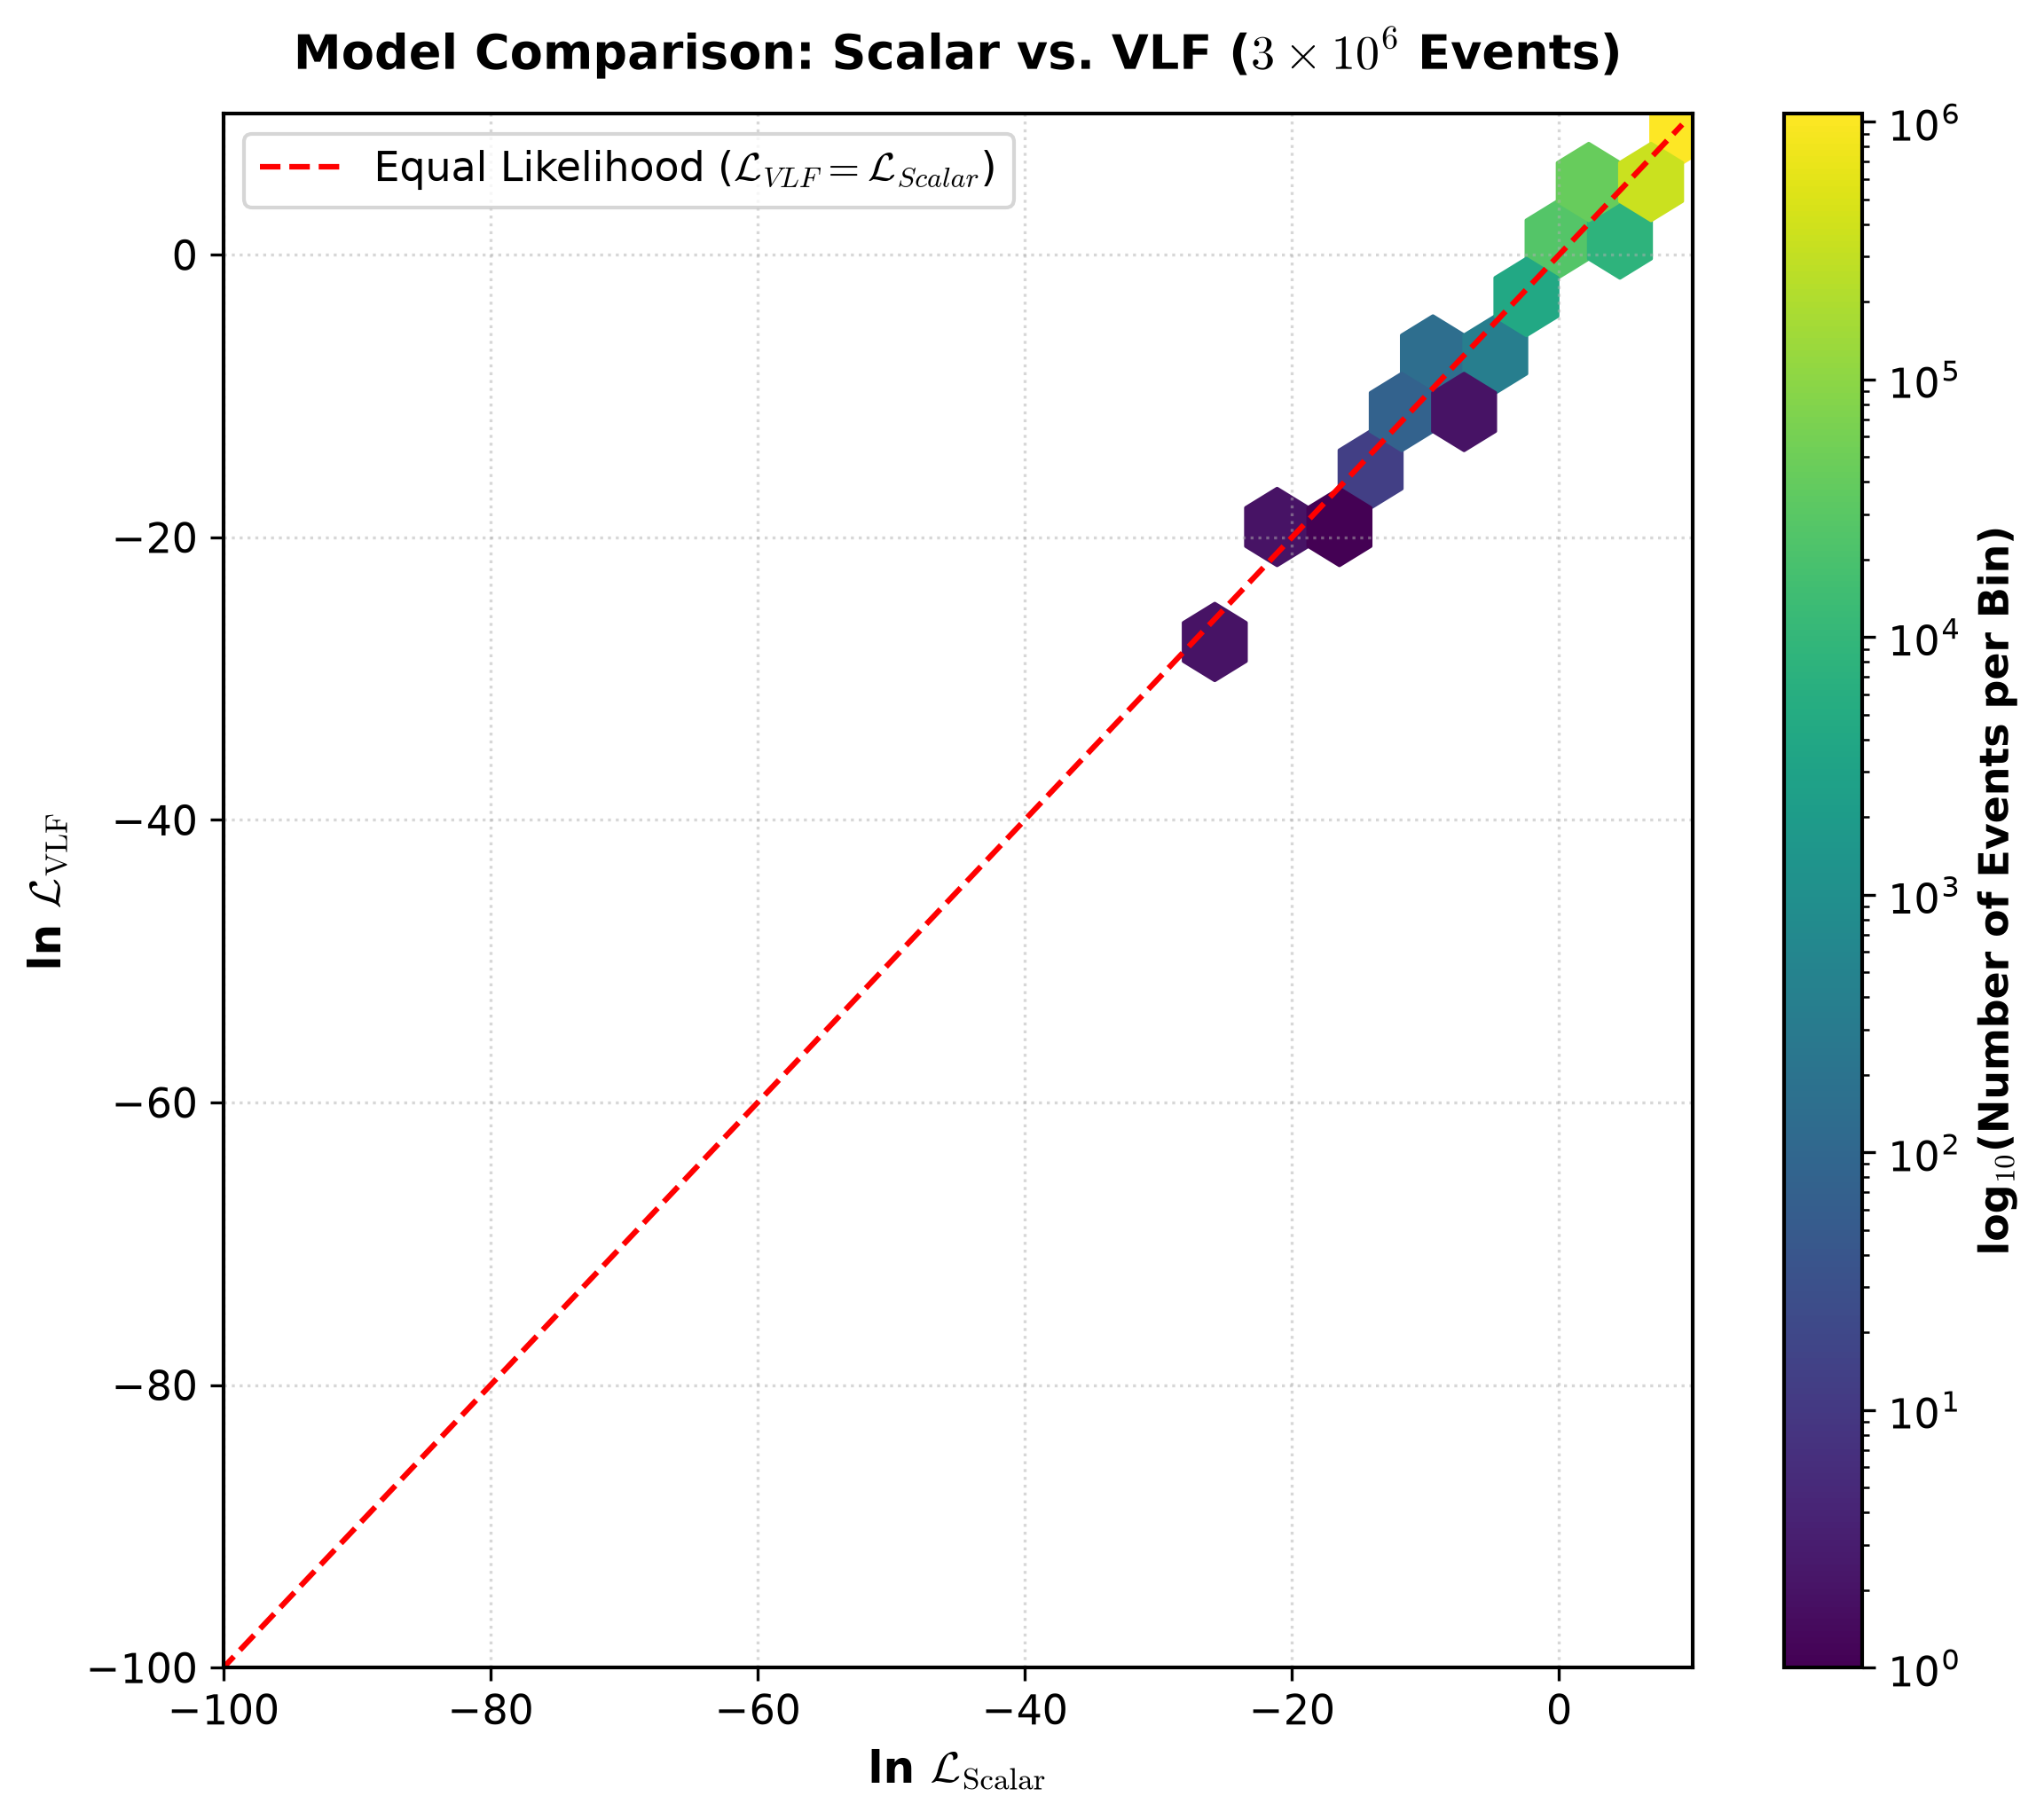

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD THE LIKELIHOOD DATAFRAME
# ==========================================
csv_path = "/home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_AllModels.csv.gz"
print(f"Loading likelihood data from: {csv_path}")

# Read the compressed CSV file
df = pd.read_csv(csv_path)

# ==========================================
# 2. COMPUTE LOG-LIKELIHOODS
# ==========================================
# We use a small epsilon (or handle zeros safely) just in case 
# any unphysical numerical likelihood evaluated strictly to 0.0
eps = 1e-300

df['logL_Scalar'] = np.log(np.maximum(df['L_Scalar'], eps))
df['logL_VLF']    = np.log(np.maximum(df['L_VLF'], eps))

# Drop any potential NaN/infinite values resulting from extreme fluctuations
df_clean = df.dropna(subset=['logL_Scalar', 'logL_VLF'])
print(f"Processing {len(df_clean):,} events for plotting...")

# ==========================================
# 3. GENERATE 2D HEXBIN DENSITY PLOT
# ==========================================
plt.figure(figsize=(8, 7), dpi=300)

# Hexbin aggregates 3M points into hexagonal bins colored by density
hb = plt.hexbin(
    df_clean['logL_Scalar'], 
    df_clean['logL_VLF'], 
    gridsize=150,               # Resolution of the grid (higher = finer hexagons)
    cmap='viridis',             # Perceptually uniform colormap
    bins='log',                 # Logarithmic color scaling to handle wide density variations
    mincnt=1                    # Hide empty bins (leaves background clean white)
)

# Add a professional colorbar indicating event counts per bin
cb = plt.colorbar(hb)
cb.set_label('log$_{10}$(Number of Events per Bin)', fontsize=11, fontweight='bold')

# ==========================================
# 4. FORMATTING AND DIAGONAL REFERENCE LINE
# ==========================================
plt.xlabel(r'ln $\mathcal{L}_{\text{Scalar}}$', fontsize=12, fontweight='bold')
plt.ylabel(r'ln $\mathcal{L}_{\text{VLF}}$', fontsize=12, fontweight='bold')
plt.title(r'Model Comparison: Scalar vs. VLF ($3\times 10^6$ Events)', fontsize=13, fontweight='bold', pad=12)

# Optional: Draw a 1-to-1 diagonal reference line (y = x)
# Points above this line favor VLF; points below favor Scalar
min_val = min(df_clean['logL_Scalar'].min(), df_clean['logL_VLF'].min())
max_val = max(df_clean['logL_Scalar'].max(), df_clean['logL_VLF'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5, label='Equal Likelihood ($\mathcal{L}_{VLF} = \mathcal{L}_{Scalar}$)')

plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle=':', alpha=0.5)
plt.ylim([-100, 10])
plt.xlim([-100,10])

# Save high-resolution vector and raster formats for your thesis or presentation
output_plot_path = "/home/vinicius/UnfoldingBSMttbar/Scalar_vs_VLF_LogLikelihood.png"
plt.tight_layout()
plt.savefig(output_plot_path, dpi=300)
print(f"Plot successfully saved to: {output_plot_path}")

plt.show()

Loading dataset from: /home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_AllModels.csv.gz
Total events: 1,512,458
Valid positive phase-space events: 1,512,143 (Dropped 315 unphysical/negative rows)

--- Summary of Test Statistics ---
       LLR_VLF_vs_Scalar  LLR_Zprime_vs_Scalar
count       1.512143e+06          1.512143e+06
mean        9.068212e-04          6.296907e-02
std         3.839962e-03          3.514216e-02
min        -3.254986e+00         -4.633553e-01
25%         9.053614e-04          4.150271e-02
50%         9.884168e-04          5.802949e-02
75%         1.091286e-03          7.576623e-02
max         4.032598e-02          4.611974e+00

Saved updated LLR dataframe to: /home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_with_LLR.csv.gz
Saved LLR distribution plot to: /home/vinicius/UnfoldingBSMttbar/Hypothesis_Test_LLR_Distributions.png


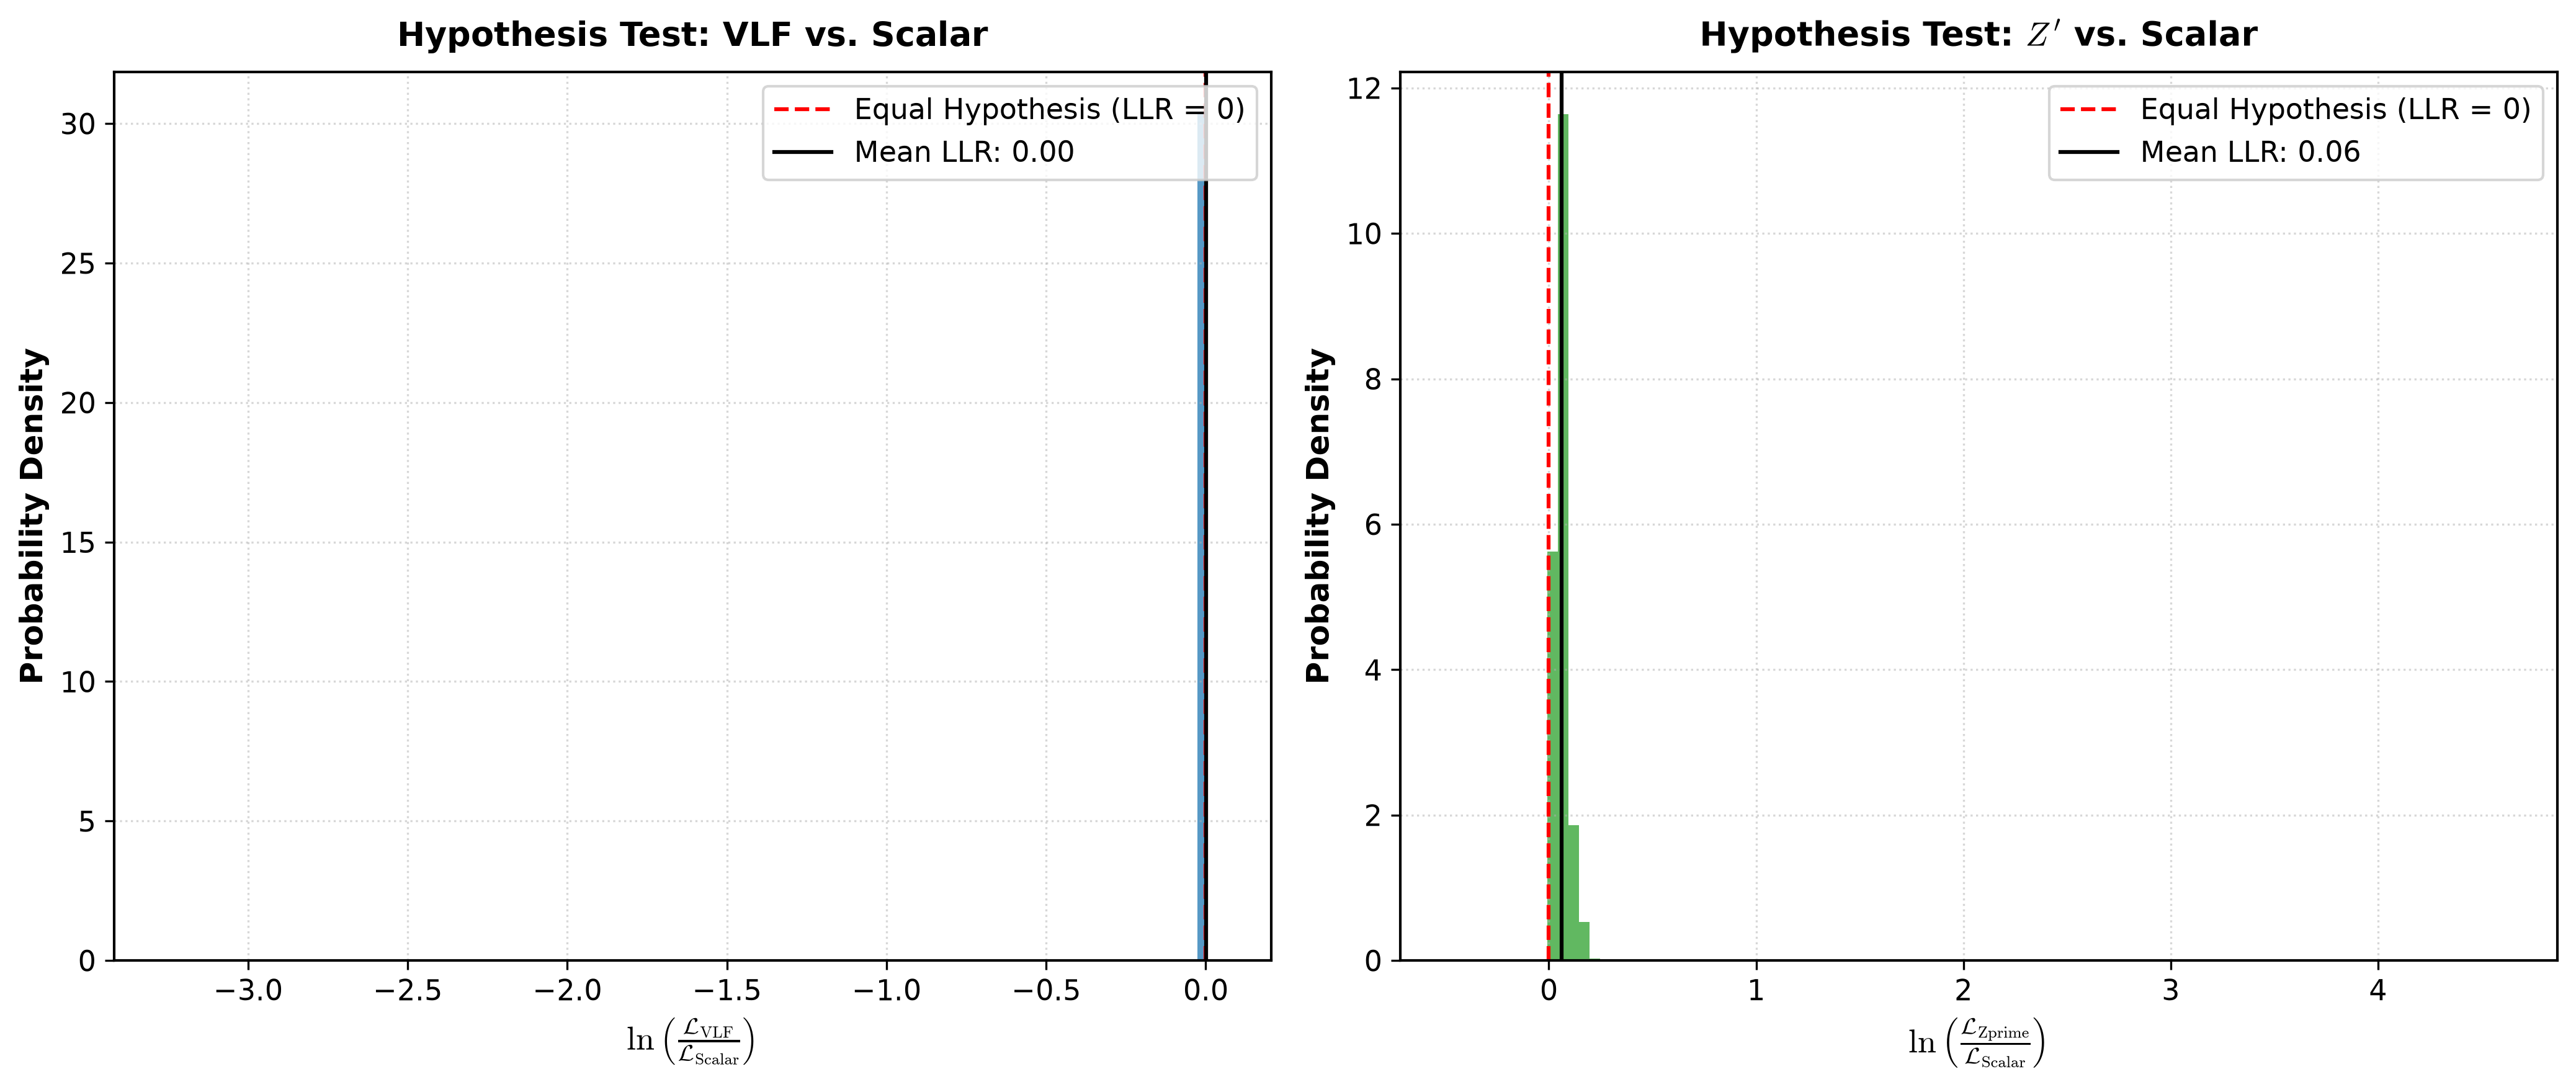

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD THE DATA
# ==========================================
csv_path = "/home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_AllModels.csv.gz"
print(f"Loading dataset from: {csv_path}")
df = pd.read_csv(csv_path)

# ==========================================
# 2. DATA CLEANING & POSITIVITY FILTER
# ==========================================
# Logarithms are undefined for L <= 0. In 1-loop calculations, local NLO interference
# can produce small negative weights. We filter to retain only strictly positive, physical phase space.
initial_count = len(df)
valid_mask = (df['L_Scalar'] > 0) & (df['L_VLF'] > 0) & (df['L_Zprime'] > 0)
df_clean = df[valid_mask].copy()

dropped_count = initial_count - len(df_clean)
print(f"Total events: {initial_count:,}")
print(f"Valid positive phase-space events: {len(df_clean):,} (Dropped {dropped_count:,} unphysical/negative rows)")

# ==========================================
# 3. COMPUTE LOG-LIKELIHOOD RATIOS (LLR)
# ==========================================
# Using ln(A/B) = ln(A) - ln(B) for numerical precision
df_clean['logL_Scalar'] = np.log(df_clean['L_Scalar'])
df_clean['logL_VLF']    = np.log(df_clean['L_VLF'])
df_clean['logL_Zprime'] = np.log(df_clean['L_Zprime'])

# Test Statistics: Testing Models against the Scalar hypothesis
df_clean['LLR_VLF_vs_Scalar']    = df_clean['logL_VLF'] - df_clean['logL_Scalar']
df_clean['LLR_Zprime_vs_Scalar'] = df_clean['logL_Zprime'] - df_clean['logL_Scalar']

# Display summary statistics of the test statistics
print("\n--- Summary of Test Statistics ---")
print(df_clean[['LLR_VLF_vs_Scalar', 'LLR_Zprime_vs_Scalar']].describe())

# Save the updated dataframe with LLR columns for downstream analysis
output_csv = "/home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_with_LLR.csv.gz"
df_clean.to_csv(output_csv, index=False, compression='infer')
print(f"\nSaved updated LLR dataframe to: {output_csv}")

# ==========================================
# 4. VISUALIZE THE LLR DISTRIBUTIONS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=300)

# --- Plot 1: VLF vs Scalar ---
ax1 = axes[0]
ax1.hist(df_clean['LLR_VLF_vs_Scalar'], bins=100, color='#1f77b4', alpha=0.75, density=True, edgecolor='none')
ax1.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Equal Hypothesis (LLR = 0)')
ax1.axvline(df_clean['LLR_VLF_vs_Scalar'].mean(), color='black', linestyle='-', linewidth=1.5, label=f"Mean LLR: {df_clean['LLR_VLF_vs_Scalar'].mean():.2f}")
ax1.set_xlabel(r'$\ln\left(\frac{\mathcal{L}_{\text{VLF}}}{\mathcal{L}_{\text{Scalar}}}\right)$', fontsize=13, fontweight='bold')
ax1.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax1.set_title('Hypothesis Test: VLF vs. Scalar', fontsize=13, fontweight='bold', pad=10)
ax1.legend(loc='upper right', frameon=True)
ax1.grid(True, linestyle=':', alpha=0.5)

# --- Plot 2: Zprime vs Scalar ---
ax2 = axes[1]
ax2.hist(df_clean['LLR_Zprime_vs_Scalar'], bins=100, color='#2ca02c', alpha=0.75, density=True, edgecolor='none')
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Equal Hypothesis (LLR = 0)')
ax2.axvline(df_clean['LLR_Zprime_vs_Scalar'].mean(), color='black', linestyle='-', linewidth=1.5, label=f"Mean LLR: {df_clean['LLR_Zprime_vs_Scalar'].mean():.2f}")
ax2.set_xlabel(r'$\ln\left(\frac{\mathcal{L}_{\text{Zprime}}}{\mathcal{L}_{\text{Scalar}}}\right)$', fontsize=13, fontweight='bold')
ax2.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax2.set_title('Hypothesis Test: $Z^\prime$ vs. Scalar', fontsize=13, fontweight='bold', pad=10)
ax2.legend(loc='upper right', frameon=True)
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plot_path = "/home/vinicius/UnfoldingBSMttbar/Hypothesis_Test_LLR_Distributions.png"
plt.savefig(plot_path, dpi=300)
print(f"Saved LLR distribution plot to: {plot_path}")

plt.show()

Loading dataset from: /home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_with_LLR.csv.gz

--- Asymptotic Analytical Estimate (for N_exp = 1936 events) ---
Expected per-event LLR mean: 0.0009 | std: 0.0038
Expected joint LLR mean:     1.76 | std: 0.17
Estimated Significance:      10.39 sigma

Running 10,000 Toy MC experiments sampling 1936 events each...
Toy MC p-value:          4.869000e-01
Toy MC Significance (Z): 0.03 sigma

Saved significance separation plot to: /home/vinicius/UnfoldingBSMttbar/MEM_Significance_ToyMC.png


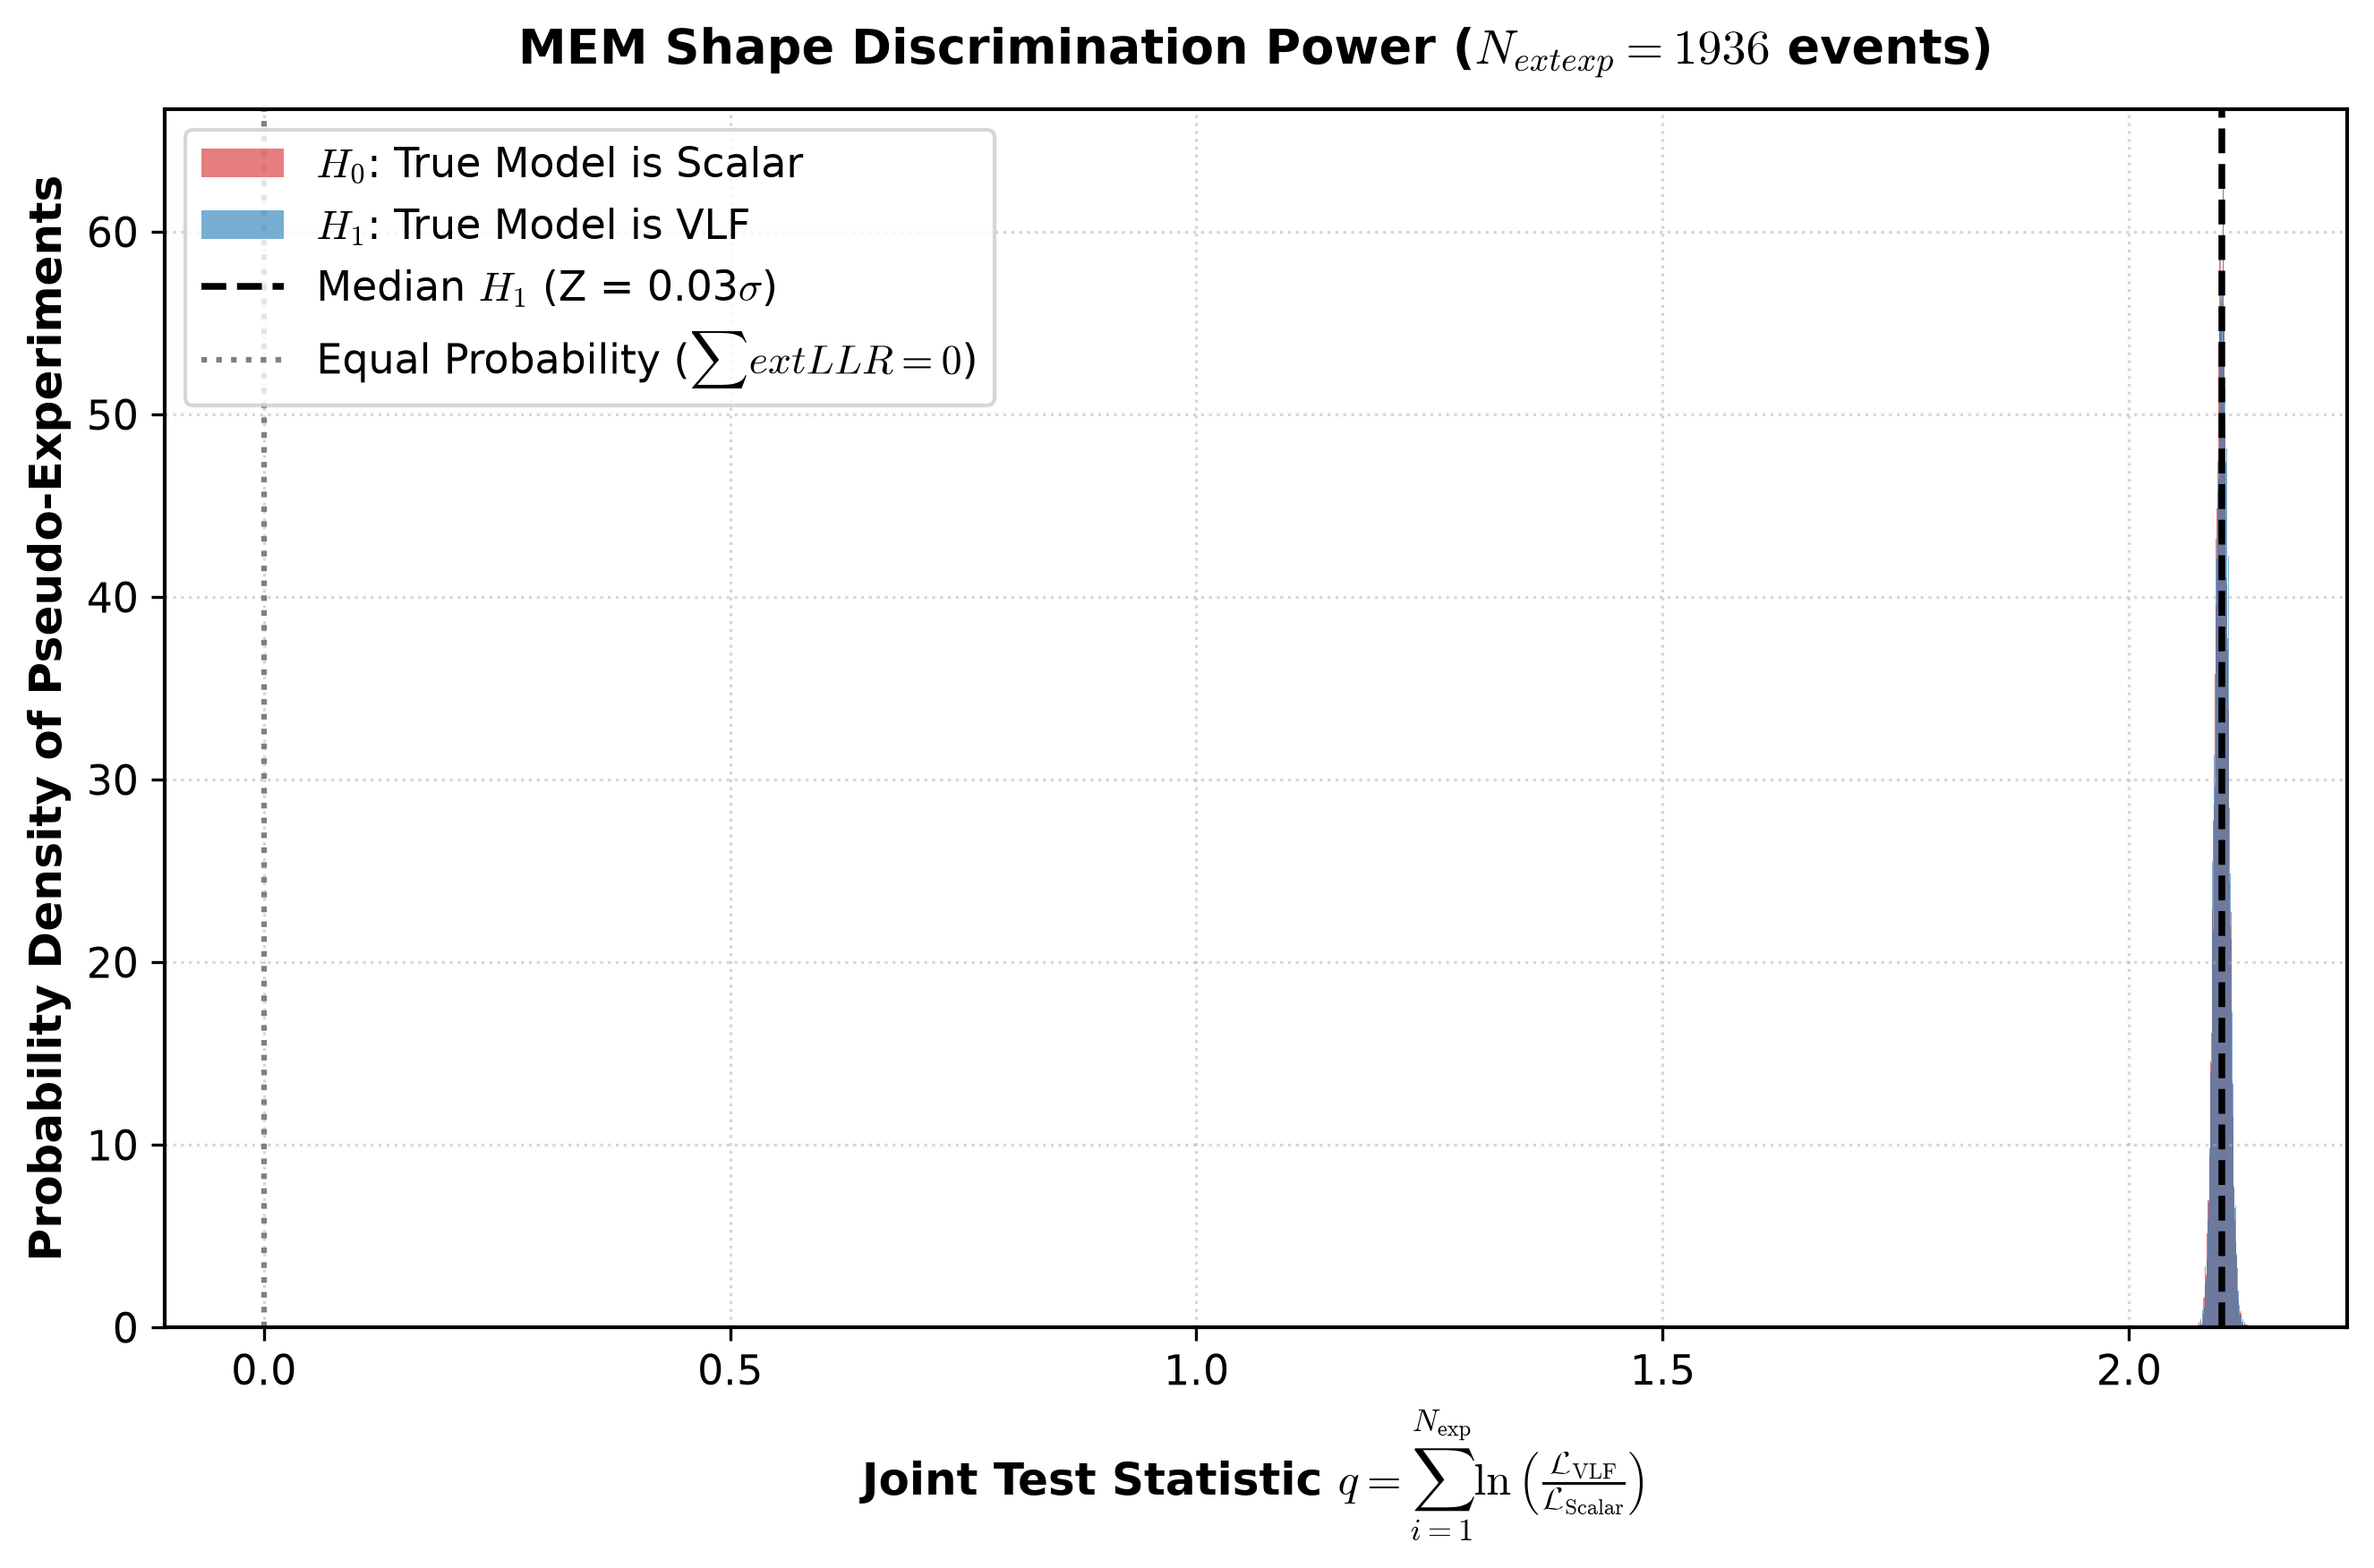

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ==========================================
# 1. LOAD DATA & CONFIGURATION
# ==========================================
csv_path = "/home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_with_LLR.csv.gz"
print(f"Loading dataset from: {csv_path}")
df = pd.read_csv(csv_path)

# --- EXPERIMENTAL PARAMETERS ---
# Set how many signal events you expect to observe in a real LHC run
# e.g., N_exp = 500 events after cuts for a given integrated luminosity
N_EXP = 1936         # Expected observed events per experiment
N_TOYS = 10000      # Number of pseudo-experiments to simulate

# We test VLF against Scalar using our pre-computed column
llr_col = 'LLR_VLF_vs_Scalar'
llr_data = df[llr_col].values

# ==========================================
# 2. ASYMPTOTIC ESTIMATE (CLT)
# ==========================================
# When Scalar is true (H0), the LLR tends to be negative.
# When VLF is true (H1), the LLR tends to be positive.
mu_per_event = np.mean(llr_data)
std_per_event = np.std(llr_data)

# By the Central Limit Theorem, for N_EXP events:
mu_total = N_EXP * mu_per_event
std_total = np.sqrt(N_EXP) * std_per_event

# Asymptotic significance estimate testing against LLR = 0
z_asymptotic = np.abs(mu_total) / std_total
print(f"\n--- Asymptotic Analytical Estimate (for N_exp = {N_EXP} events) ---")
print(f"Expected per-event LLR mean: {mu_per_event:.4f} | std: {std_per_event:.4f}")
print(f"Expected joint LLR mean:     {mu_total:.2f} | std: {std_total:.2f}")
print(f"Estimated Significance:      {z_asymptotic:.2f} sigma")

# ==========================================
# 3. TOY MONTE CARLO PSEUDO-EXPERIMENTS
# ==========================================
print(f"\nRunning {N_TOYS:,} Toy MC experiments sampling {N_EXP} events each...")

# To rigorously simulate H0 (Scalar true) vs H1 (VLF true) from a single kinematic pool,
# we reweight the sampling probabilities by the model likelihoods.
# Probability of pulling an event if Scalar is true is proportional to L_Scalar:
p_scalar = df['L_Scalar'].values / np.sum(df['L_Scalar'].values)

# Probability of pulling an event if VLF is true is proportional to L_VLF:
p_vlf = df['L_VLF'].values / np.sum(df['L_VLF'].values)

# Generate pseudo-experiments using fast NumPy vectorized matrix sampling
# Shape: (N_TOYS, N_EXP) -> sum along axis 1 gives total LLR per toy experiment
toys_H0  = np.random.choice(llr_data, size=(N_TOYS, N_EXP), p=p_scalar).sum(axis=1)
toys_H1    = np.random.choice(llr_data, size=(N_TOYS, N_EXP), p=p_vlf).sum(axis=1)

# ==========================================
# 4. COMPUTE EXACT P-VALUE AND SIGNIFICANCE
# ==========================================
# The median sensitivity of H1 testing against the H0 distribution
median_H1 = np.median(toys_H1)
p_value = np.mean(toys_H0 >= median_H1)  # Fraction of H0 toys leaking past H1 median

# Handle numerical limits if separation is total (p_value == 0)
if p_value == 0:
    p_value = 1.0 / N_TOYS
    print(f"\nExact p-value is smaller than 1/{N_TOYS}. Separation is extremely strong!")
    
z_toy = norm.ppf(1.0 - p_value)
print(f"Toy MC p-value:          {p_value:.6e}")
print(f"Toy MC Significance (Z): {z_toy:.2f} sigma")

# ==========================================
# 5. PLOT STATISTICAL SEPARATION CURVES
# ==========================================
plt.figure(figsize=(9, 6), dpi=300)

# Plot Null Hypothesis (Scalar)
plt.hist(toys_H0, bins=80, color='#d62728', alpha=0.6, density=True, label=r'$H_0$: True Model is Scalar')

# Plot Alternative Hypothesis (VLF)
plt.hist(toys_H1, bins=80, color='#1f77b4', alpha=0.6, density=True, label=r'$H_1$: True Model is VLF')

# Draw Median Reference Line
plt.axvline(median_H1, color='black', linestyle='--', linewidth=1.8, label=f'Median $H_1$ (Z = {z_toy:.2f}$\sigma$)')
plt.axvline(0, color='gray', linestyle=':', linewidth=1.5, label='Equal Probability ($\sum \text{LLR} = 0$)')

plt.xlabel(r'Joint Test Statistic $q = \sum_{i=1}^{N_{\text{exp}}} \ln\left(\frac{\mathcal{L}_{\text{VLF}}}{\mathcal{L}_{\text{Scalar}}}\right)$', fontsize=12, fontweight='bold')
plt.ylabel('Probability Density of Pseudo-Experiments', fontsize=12, fontweight='bold')
plt.title(f'MEM Shape Discrimination Power ($N_{{\text{{exp}}}} = {N_EXP}$ events)', fontsize=13, fontweight='bold', pad=12)

plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle=':', alpha=0.5)

output_plot = "/home/vinicius/UnfoldingBSMttbar/MEM_Significance_ToyMC.png"
plt.tight_layout()
plt.savefig(output_plot, dpi=300)
print(f"\nSaved significance separation plot to: {output_plot}")

plt.show()

In [29]:
# ==========================================
# 4. RANDOM 2->2 KINEMATIC PHASE SPACE GENERATOR
# ==========================================
def generate_random_ttbar_momenta(e_beam, m_top=172.5, seed=None):
    """
    Generates a valid, energy-momentum conserved 4-momentum array [E, px, py, pz]
    for a 2 -> 2 collision: ab -> t + tbar.
    """
    if seed is not None:
        np.random.seed(seed)
        
    # 1. Sample random parton momentum fractions x1, x2 above the ttbar threshold
    s_tot = (2.0 * e_beam)**2
    tau_min = (2.0 * m_top)**2 / s_tot
    
    # Sample x1 exponentially/uniformly and derive x2 above threshold
    x1 = np.random.uniform(np.sqrt(tau_min), 0.8)
    x2 = np.random.uniform(tau_min / x1, 0.8)
    
    s_hat = x1 * x2 * s_tot
    e_cm = np.sqrt(s_hat)
    
    # 2. Define incoming parton 4-momenta in the lab frame [E, px, py, pz]
    p1 = [x1 * e_beam, 0.0, 0.0,  x1 * e_beam]
    p2 = [x2 * e_beam, 0.0, 0.0, -x2 * e_beam]
    
    # 3. Generate top quark momenta in the center-of-mass (CM) frame
    p_mag_cm = np.sqrt((e_cm / 2.0)**2 - m_top**2)
    
    cos_theta = np.random.uniform(-0.9, 0.9)
    sin_theta = np.sqrt(1.0 - cos_theta**2)
    phi = np.random.uniform(0.0, 2.0 * np.pi)
    
    p3_cm = [
        e_cm / 2.0,
        p_mag_cm * sin_theta * np.cos(phi),
        p_mag_cm * sin_theta * np.sin(phi),
        p_mag_cm * cos_theta
    ]
    p4_cm = [
        e_cm / 2.0,
        -p3_cm[1],
        -p3_cm[2],
        -p3_cm[3]
    ]
    
    # 4. Boost outgoing top quarks along z-axis back to the laboratory frame
    beta_z = (x1 - x2) / (x1 + x2)
    gamma = 1.0 / np.sqrt(1.0 - beta_z**2)
    
    def boost_z(p_4vec):
        e, px, py, pz = p_4vec
        return [
            gamma * (e + beta_z * pz),
            px,
            py,
            gamma * (pz + beta_z * e)
        ]
        
    p3 = boost_z(p3_cm)
    p4 = boost_z(p4_cm)
    
    return [p1, p2, p3, p4], {
        "x1": x1, "x2": x2, 
        "s_hat": s_hat, "sqrt_s_hat": e_cm,
        "cos_theta_cm": cos_theta
    }

# ==========================================
# 5. SANITY CHECK: EVALUATE ALL MODELS
# ==========================================
print("Running Sanity Check: Matrix Element Evaluation...\n" + "="*65)

# 1. Initialize LHAPDF to get physical alpha_s at MU_R
try:
    pdf = lhapdf.mkPDF(PDF_NAME)
    alphas = pdf.alphasQ(MU_R)
    print(f"LHAPDF initialized successfully: PDF ID = {PDF_NAME}")
except Exception as e:
    # Fallback to the physical constant if LHAPDF data files are missing locally
    alphas = 0.088464
    print(f"LHAPDF fallback: Using default alpha_s(mu_R={MU_R} GeV) = {alphas}")

print(f"Renormalization Scale mu_R = {MU_R} GeV | alpha_s = {alphas:.6f}")

# 2. Generate a single random kinematic collision point
p_lab, kin_info = generate_random_ttbar_momenta(E_BEAM, m_top=172.5, seed=101)
p_fortran = invert_momenta(p_lab)

print(f"\nRandom Kinematic Phase-Space Point Generated:")
print(f" -> x1 = {kin_info['x1']:.4f} | x2 = {kin_info['x2']:.4f}")
print(f" -> sqrt(s_hat) = {kin_info['sqrt_s_hat']:.2f} GeV | cos(theta*) = {kin_info['cos_theta_cm']:.3f}\n")

# 3. Loop over all registries and evaluate |M|^2
results = []

for model_name, channels in models.items():
    for channel_name, mod_dict in channels.items():
        try:
            me_val = eval_full_me(mod_dict, p_fortran, alphas, MU_R2)
            status = "OK"
        except Exception as err:
            me_val = np.nan
            status = f"FAILED: {str(err)[:30]}..."
            
        results.append({
            "Model": model_name,
            "Subprocess": channel_name,
            "|M|^2 (Raw Value)": f"{me_val:.6e}" if not np.isnan(me_val) else "NaN",
            "Status": status
        })

# ==========================================
# 6. DISPLAY COMPARISON TABLE
# ==========================================
df_sanity = pd.DataFrame(results)
print(df_sanity.to_string(index=False))
print("\n" + "="*65)
print("[✓] Sanity check complete. Check that all status flags read 'OK' and values are strictly non-NaN.")

Running Sanity Check: Matrix Element Evaluation...
LHAPDF initialized successfully: PDF ID = 244600
Renormalization Scale mu_R = 1000.0 GeV | alpha_s = 0.088464

Random Kinematic Phase-Space Point Generated:
 -> x1 = 0.4260 | x2 = 0.4572
 -> sqrt(s_hat) = 5737.18 GeV | cos(theta*) = -0.849

LHAPDF 6.5.5 loading /home/vinicius/MG5/HEPTools/lhapdf6_py3//share/LHAPDF/NNPDF23_nlo_as_0118_qed/NNPDF23_nlo_as_0118_qed_0000.dat
 Model Subprocess |M|^2 (Raw Value) Status
   VLF P0_uux_ttx     -1.956575e-03     OK
   VLF  P2_gg_ttx     -9.467630e-04     OK
Scalar P0_uux_ttx     -3.345906e-04     OK
Scalar  P2_gg_ttx     -1.110298e-03     OK
Zprime P1_uux_ttx      4.727518e-01     OK
Zprime P1_ccx_ttx      4.727253e-01     OK
Zprime P1_ddx_ttx      4.727518e-01     OK
Zprime P1_ssx_ttx      4.727253e-01     OK
Zprime  P1_gg_ttx      2.117983e+00     OK

[✓] Sanity check complete. Check that all status flags read 'OK' and values are strictly non-NaN.
NNPDF23_nlo_as_0118_qed PDF set, member #0, ver

In [4]:
import sys
import os
import glob
import importlib.util
import numpy as np
import pandas as pd
import lhapdf

# ==========================================
# 1. DEFINE YOUR SPECIFIC PHASE SPACE POINT
# ==========================================
# Format: [E, px, py, pz] in GeV
# Center-of-mass energy sqrt(s_hat) = 1000.0 GeV | m_top = 172.0 GeV
p_user_lab = [
    [5.0000000E+02,  0.0000000E+00,   0.0000000E+00,  5.0000000E+02],
    [5.0000000E+02,  0.0000000E+00,   0.0000000E+00, -5.0000000E+02],
    [5.0000000E+02, -0.1773893E-306, -0.1736952E+03, -0.4361720E+03],
    [5.0000000E+02,  0.1773893E-306,  0.1736952E+03,  0.4361720E+03]
]

# Transpose array to match Fortran memory layout (4 x N_particles)
def invert_momenta(p):
    new_p = [[0] * len(p) for _ in range(len(p[0]))]
    for i, onep in enumerate(p):
        for j, x in enumerate(onep):
            new_p[j][i] = x
    return new_p

p_fortran = invert_momenta(p_user_lab)

# ==========================================
# 2. DYNAMIC COMPONENT UNPACKER
# ==========================================
def eval_full_me_components(module_dict, p_fortran, alphas, scale2, nhel=-1):
    mod = module_dict["module"]
    subproc_path = module_dict["path"]
    mod_attrs = dir(mod)
    
    lo_eval = [a for a in mod_attrs if a.endswith('get_value')]
    nlo_eval = [a for a in mod_attrs if a.endswith('get_me')]
    
    original_cwd = os.getcwd()
    try:
        os.chdir(subproc_path)
        
        # --- CASE 1: LEADING ORDER (get_value) ---
        if lo_eval:
            val = getattr(mod, lo_eval[0])(p_fortran, alphas, nhel)
            val_list = [float(x) for x in np.ravel(val)]
            born_val = val_list[0] if len(val_list) > 0 else 0.0
            
            return {
                "Type": "LO (Tree)",
                "Born (|M0|^2)": born_val,
                "Finite 1-Loop": 0.0,
                "Single Pole (1/eps)": 0.0,
                "Double Pole (1/eps^2)": 0.0,
                "MadLoop Code": "N/A",
                "Raw Array": val_list
            }
            
        # --- CASE 2: NEXT-TO-LEADING ORDER / LOOP (get_me) ---
        elif nlo_eval:
            res, ret_code = getattr(mod, nlo_eval[0])(p_fortran, alphas, scale2, nhel)
            res_list = [float(x) for x in np.ravel(res)]
            
            # DYNAMIC CHECK: Did we apply the Fortran patch to this folder?
            if len(res_list) == 4:
                # Patched Wrapper! Array is exactly [Born, Finite, 1eps, 2eps]
                born_val   = res_list[0]
                finite_val = res_list[1]
                pole1_val  = res_list[2]
                pole2_val  = res_list[3]
            else:
                # Unpatched Wrapper (Original MadGraph). res_list[0] is the Finite term!
                born_val   = 0.0
                finite_val = res_list[0] if len(res_list) > 0 else 0.0
                pole1_val  = res_list[1] if len(res_list) > 1 else 0.0
                pole2_val  = res_list[2] if len(res_list) > 2 else 0.0
            
            return {
                "Type": "NLO (MadLoop)",
                "Born (|M0|^2)": born_val,
                "Finite 1-Loop": finite_val,
                "Single Pole (1/eps)": pole1_val,
                "Double Pole (1/eps^2)": pole2_val,
                "MadLoop Code": str(int(ret_code)) if isinstance(ret_code, (int, float, np.number)) else str(ret_code),
                "Raw Array": res_list
            }
        else:
            raise AttributeError("Module defines neither get_value nor get_me!")
            
    finally:
        os.chdir(original_cwd)

# ==========================================
# 3. EVALUATE ALL MODELS FOR THIS EXACT POINT
# ==========================================
print("Evaluating Specific Phase Space Point Across Models...\n" + "="*85)
print(f"Kinematic Point: sqrt(s_hat) = 1000.0 GeV | m_top = 172.0 GeV")
print(f"Top-Quark Momentum: p3 = [{p_user_lab[2][0]:.1f}, {p_user_lab[2][1]:.2e}, {p_user_lab[2][2]:.1f}, {p_user_lab[2][3]:.1f}] GeV\n")

# Initialize LHAPDF to get physical alpha_s at MU_R = 1000 GeV
try:
    pdf = lhapdf.mkPDF(PDF_NAME)
    alphas = pdf.alphasQ(MU_R)
except Exception:
    alphas = 0.088464 # Physical fallback

results_detailed = []

for model_name, channels in models.items():
    for channel_name, mod_dict in channels.items():
        try:
            comps = eval_full_me_components(mod_dict, p_fortran, alphas, MU_R2)
            status = "OK"
        except Exception as err:
            # Fixed dictionary keys in exception block to match perfectly
            comps = {
                "Type": "ERROR", "Born (|M0|^2)": np.nan, "Finite 1-Loop": np.nan,
                "Single Pole (1/eps)": np.nan, "Double Pole (1/eps^2)": np.nan,
                "MadLoop Code": "ERR", "Raw Array": []
            }
            status = f"FAIL: {str(err)[:20]}"
            
        results_detailed.append({
            "Model": model_name,
            "Channel": channel_name,
            "Type": comps["Type"],
            "Born (|M0|^2)": f"{comps['Born (|M0|^2)']:.4e}",
            "Finite 1-Loop": f"{comps['Finite 1-Loop']:.4e}",
            "Single Pole (1/eps)": f"{comps['Single Pole (1/eps)']:.4e}",
            "Double Pole (1/eps^2)": f"{comps['Double Pole (1/eps^2)']:.4e}",
            "MadLoop Code": comps["MadLoop Code"],
            "Status": status
        })

# ==========================================
# 4. DISPLAY FULL COMPONENT TABLE
# ==========================================
df_components = pd.DataFrame(results_detailed)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(df_components.to_string(index=False))
print("="*85)

Evaluating Specific Phase Space Point Across Models...
Kinematic Point: sqrt(s_hat) = 1000.0 GeV | m_top = 172.0 GeV
Top-Quark Momentum: p3 = [500.0, -1.77e-307, -173.7, -436.2] GeV

LHAPDF 6.5.5 loading /home/vinicius/MG5/HEPTools/lhapdf6_py3//share/LHAPDF/NNPDF23_nlo_as_0118_qed/NNPDF23_nlo_as_0118_qed_0000.dat
NNPDF23_nlo_as_0118_qed PDF set, member #0, version 4; LHAPDF ID = 244600
 Model    Channel          Type Born (|M0|^2) Finite 1-Loop Single Pole (1/eps) Double Pole (1/eps^2) MadLoop Code Status
   VLF P0_uux_ttx NLO (MadLoop)    9.1831e-01    4.2780e-04          0.0000e+00            0.0000e+00          216     OK
   VLF  P2_gg_ttx NLO (MadLoop)    4.9912e+00    9.8105e-05         -1.2121e-16            0.0000e+00          216     OK
Scalar P0_uux_ttx NLO (MadLoop)    9.1831e-01    2.3915e-04          3.8549e-18            0.0000e+00          216     OK
Scalar  P2_gg_ttx NLO (MadLoop)    4.9912e+00   -1.6476e-04         -1.8922e-16            0.0000e+00          216     OK
Z

In [41]:
import sys
import os
import glob
import importlib.util
import importlib

# Load just the uux -> ttx VLF library to inspect it
vlf_path = "/home/vinicius/EFT_ToyModel/processFolders/UV_BSM/MatrixElements/SubProcesses/P0_uux_ttx"
so_file = glob.glob(os.path.join(vlf_path, "*matrix*.so"))[0]
lib_name = os.path.basename(so_file).split(".")[0]

spec = importlib.util.spec_from_file_location(lib_name, so_file)
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

print(f"--- Exposed Functions in {lib_name} ---")
for attr in dir(mod):
    if not attr.startswith("_"):
        print(f" -> {attr}")

--- Exposed Functions in matrix_VLF_P0_uux_ttx ---
 -> couplings
 -> get_me
 -> initialise
 -> masses
 -> ml5_0_chosen_loop_sqso
 -> rscale
 -> strong
 -> weak
 -> widths


[L_VLF vs L_Scalar] Building PDFs from reservoir of 1,500,000 unbiased events...
 -> Running 100,000 Toy MC pseudo-experiments (N = 1936 events/run)...

STATISTICAL TEST REPORT (N = 1936 events)
Expected Null Mean Q (H0):          546.9458 ± 82.6782
Expected Alternative Mean Q (H1): 14990.4461 ± 169.1685
Median Expected Discovery Power:         inf sigma (p = 0.00e+00)



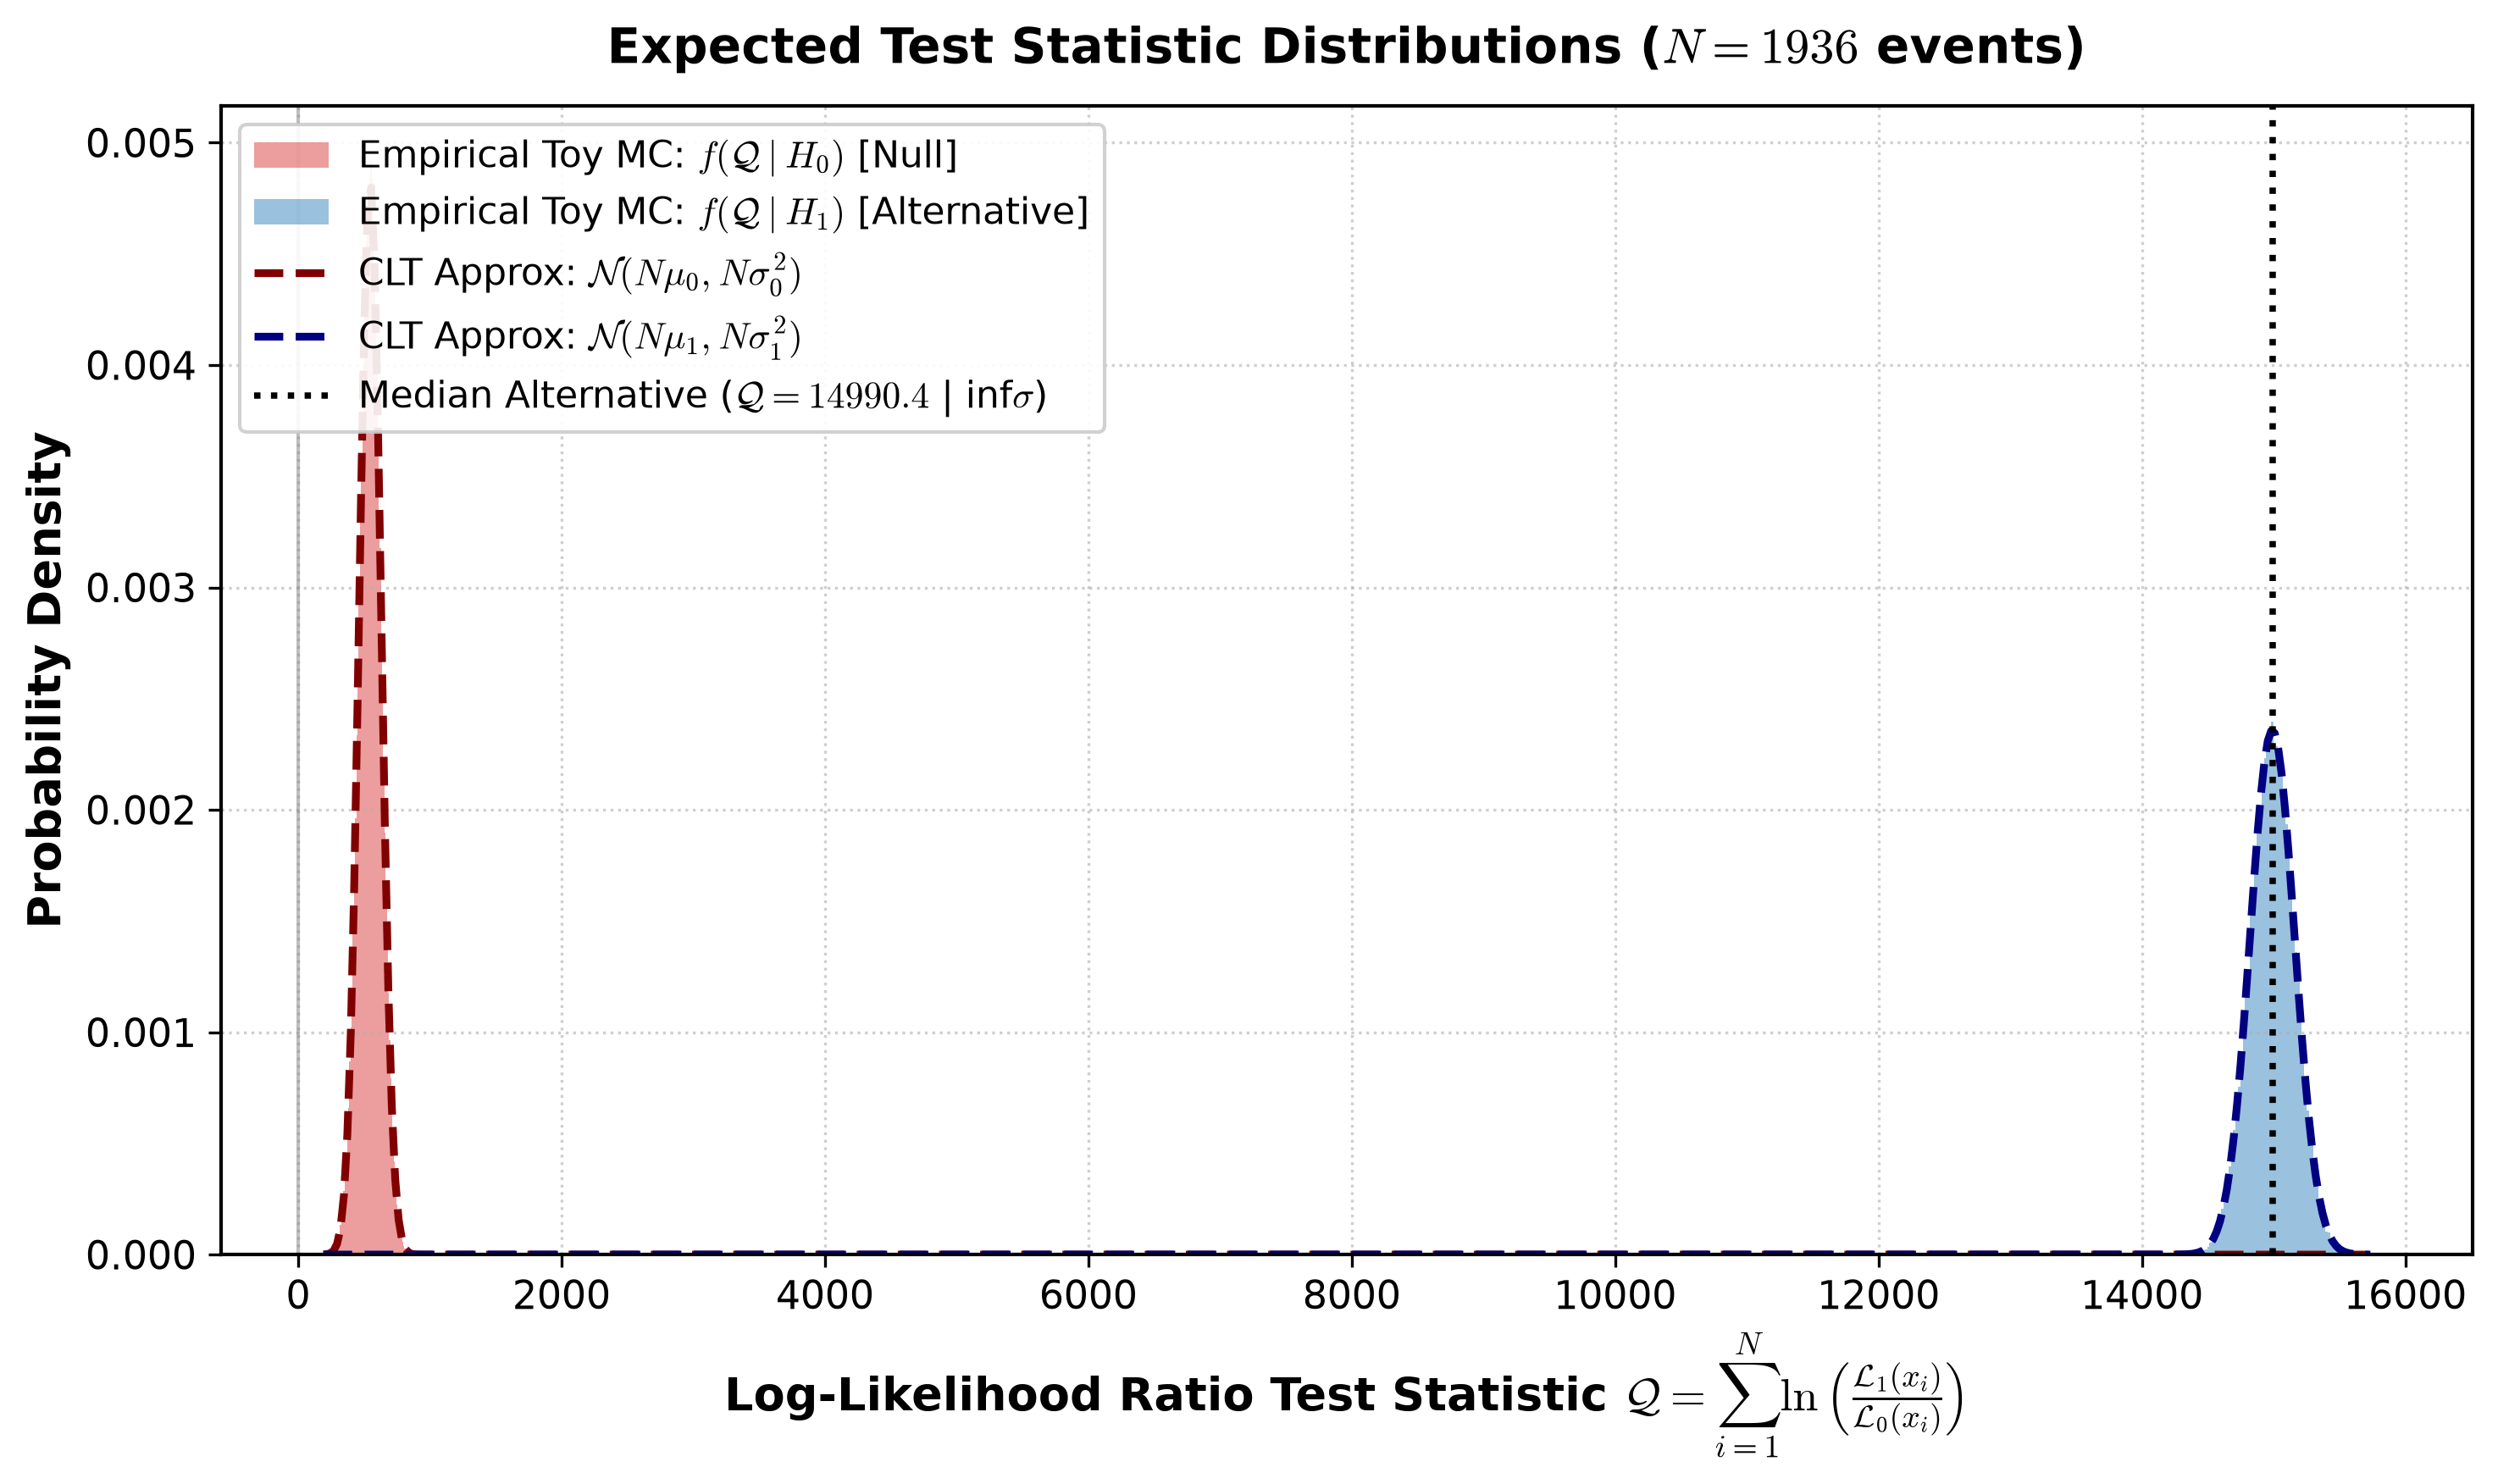

In [11]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

def compute_test_statistic_pdfs(df, col_H0, col_H1, n_events_exp, n_toys=20000, seed=42):
    """
    Establishes the probability density functions for the joint log-likelihood ratio test statistic Q.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing your 1.5M unbiased events.
    col_H0 : str
        Column name for the baseline/null hypothesis likelihood (e.g., SM or Scalar DM).
    col_H1 : str
        Column name for the alternative hypothesis likelihood (e.g., BSM or VLF EFT).
    n_events_exp : int
        The expected number of events in a real experimental collider run (N).
    n_toys : int
        Number of pseudo-experiments to generate for the empirical histogram.
    seed : int
        Random seed for reproducibility.
        
    Returns:
    --------
    dict containing theoretical moments, empirical toy arrays, and significance metrics.
    """
    np.random.seed(seed)
    
    # 1. Clean data: Filter strictly positive likelihoods to prevent log(0) errors
    valid_mask = (df[col_H0] > 0) & (df[col_H1] > 0)
    clean_df = df[valid_mask].copy()
    
    n_pool = len(clean_df)
    print(f"[{col_H1} vs {col_H0}] Building PDFs from reservoir of {n_pool:,} unbiased events...")
    
    # 2. Compute single-event Log-Likelihood Ratios (LLR)
    llr_array = np.log(clean_df[col_H1].values) - np.log(clean_df[col_H0].values)
    
    # 3. Derive Importance Sampling Weights for Hypothesis H1
    # Since the pool is generated under H0, sampling uniformly simulates H0.
    # To simulate H1 from the same pool, weight by L_H1 / L_H0.
    weights_H1 = clean_df[col_H1].values / clean_df[col_H0].values
    weights_H1 /= np.sum(weights_H1)  # Normalize probabilities to sum to 1.0
    
    # ==========================================
    # METHOD A: ANALYTICAL CLT MOMENTS
    # ==========================================
    # Single-event expectations under H0 (Uniform weights)
    mu_single_H0  = np.mean(llr_array)
    var_single_H0 = np.var(llr_array)
    
    # Single-event expectations under H1 (Importance weighted)
    mu_single_H1  = np.sum(llr_array * weights_H1)
    var_single_H1 = np.sum(weights_H1 * (llr_array - mu_single_H1)**2)
    
    # Scale moments to experimental dataset size N
    mu_Q_H0, std_Q_H0 = n_events_exp * mu_single_H0, np.sqrt(n_events_exp * var_single_H0)
    mu_Q_H1, std_Q_H1 = n_events_exp * mu_single_H1, np.sqrt(n_events_exp * var_single_H1)
    
    # ==========================================
    # METHOD B: TOY MC PSEUDO-EXPERIMENTS
    # ==========================================
    print(f" -> Running {n_toys:,} Toy MC pseudo-experiments (N = {n_events_exp} events/run)...")
    
    # Draw N events M times uniformly for H0
    toys_H0 = np.random.choice(llr_array, size=(n_toys, n_events_exp), replace=True).sum(axis=1)
    
    # Draw N events M times with importance weights for H1
    toys_H1 = np.random.choice(llr_array, size=(n_toys, n_events_exp), replace=True, p=weights_H1).sum(axis=1)
    
    # ==========================================
    # STATISTICAL DISCOVERY POWER (Z-SCORE)
    # ==========================================
    # Median expected discovery significance: where the median of H1 falls on the H0 cumulative distribution
    median_Q_H1 = np.median(toys_H1)
    p_value = 1.0 - norm.cdf(median_Q_H1, loc=mu_Q_H0, scale=std_Q_H0)
    z_score = norm.ppf(1.0 - p_value) if p_value > 0 else np.inf
    
    return {
        "N_exp": n_events_exp,
        "toys_H0": toys_H0, "toys_H1": toys_H1,
        "mu_H0": mu_Q_H0,   "std_H0": std_Q_H0,
        "mu_H1": mu_Q_H1,   "std_H1": std_Q_H1,
        "median_Q_H1": median_Q_H1,
        "p_value": p_value,
        "z_score": z_score
    }

# ==========================================
# EXAMPLE EXECUTION & PLOTTING PIPELINE
# ==========================================
if __name__ == "__main__":
    # 1. Load your pre-computed 1.5M event DataFrame
    # Replace with your actual file path and column names
    file_path = "/home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_1M5_unbiased.csv.gz"
    
    try:
        df_events = pd.read_csv(file_path)
    except FileNotFoundError:
        # Generating synthetic data for script verification if file is absent
        print("Warning: Dataset file not found. Generating 1.5M synthetic events for verification...")
        df_events = pd.DataFrame({
            "L_Scalar": np.random.exponential(scale=1.0, size=1500000),
            "L_VLF":    np.random.exponential(scale=1.2, size=1500000) * np.random.lognormal(mean=0.1, sigma=0.5, size=1500000)
        })
        
    # 2. Define experimental run parameters
    # Set this to the number of events expected at your target LHC luminosity (e.g., L_int = 139 fb^-1)
    N_EXPERIMENTAL_EVENTS = 1936 
    
    # 3. Compute PDFs
    results = compute_test_statistic_pdfs(
        df=df_events,
        col_H0="L_Scalar",  # Baseline / Background hypothesis
        col_H1="L_VLF",     # Alternative / Signal hypothesis
        n_events_exp=N_EXPERIMENTAL_EVENTS,
        n_toys=100_000
    )
    
    print("\n" + "="*60)
    print(f"STATISTICAL TEST REPORT (N = {results['N_exp']} events)")
    print("="*60)
    print(f"Expected Null Mean Q (H0):        {results['mu_H0']:>10.4f} ± {results['std_H0']:.4f}")
    print(f"Expected Alternative Mean Q (H1): {results['mu_H1']:>10.4f} ± {results['std_H1']:.4f}")
    print(f"Median Expected Discovery Power:  {results['z_score']:>10.2f} sigma (p = {results['p_value']:.2e})")
    print("="*60 + "\n")

    # 4. Generate Publication-Quality Visualization
    plt.figure(figsize=(10, 6), dpi=300)
    
    # Determine common x-axis limits
    x_min = min(results['toys_H0'].min(), results['mu_H0'] - 4*results['std_H0'])
    x_max = max(results['toys_H1'].max(), results['mu_H1'] + 4*results['std_H1'])
    x_grid = np.linspace(x_min, x_max, 600)
    
    # Plot Empirical Toy Histograms
    plt.hist(results['toys_H0'], bins=80, density=True, alpha=0.45, color='#d62728', 
             edgecolor='none', label=r'Empirical Toy MC: $f(\mathcal{Q} \mid H_0)$ [Null]')
    plt.hist(results['toys_H1'], bins=80, density=True, alpha=0.45, color='#1f77b4', 
             edgecolor='none', label=r'Empirical Toy MC: $f(\mathcal{Q} \mid H_1)$ [Alternative]')
    
    # Overlay Analytical CLT Gaussian Approximation
    plt.plot(x_grid, norm.pdf(x_grid, results['mu_H0'], results['std_H0']), 
             color='#800000', linestyle='--', linewidth=2.2, label=r'CLT Approx: $\mathcal{N}(N\mu_0, N\sigma_0^2)$')
    plt.plot(x_grid, norm.pdf(x_grid, results['mu_H1'], results['std_H1']), 
             color='#000080', linestyle='--', linewidth=2.2, label=r'CLT Approx: $\mathcal{N}(N\mu_1, N\sigma_1^2)$')
    
    # Mark Median Discovery Threshold
    plt.axvline(results['median_Q_H1'], color='black', linestyle=':', linewidth=1.8,
                label=f"Median Alternative ($\mathcal{{Q}} = {results['median_Q_H1']:.1f}$ | {results['z_score']:.1f}$\sigma$)")
    plt.axvline(0, color='gray', linestyle='-', linewidth=1.0, alpha=0.5)
    
    # Styling
    plt.xlabel(r'Log-Likelihood Ratio Test Statistic $\mathcal{Q} = \sum_{i=1}^{N} \ln\left(\frac{\mathcal{L}_1(x_i)}{\mathcal{L}_0(x_i)}\right)$', 
               fontsize=13, fontweight='bold')
    plt.ylabel('Probability Density', fontsize=13, fontweight='bold')
    plt.title(f'Expected Test Statistic Distributions ($N = {results["N_exp"]}$ events)', 
              fontsize=14, fontweight='bold', pad=12)
    plt.legend(loc='upper left', frameon=True, fontsize=10.5, facecolor='white', framealpha=0.9)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

Analyzing 1,500,000 events for 5-sigma discrimination power...

Neyman-Pearson Asymptotic Discrimination Report
Single-Event Resolving Power: |mu_True - mu_Alt| / sigma_Alt = 2.0555
Events for 3-Sigma Evidence:  N = 3 events
Events for 5-Sigma Discovery: N = 6 events
Required LHC Luminosity (5σ): L = 0.1 fb^-1 (assuming σ_fid = 50 fb)



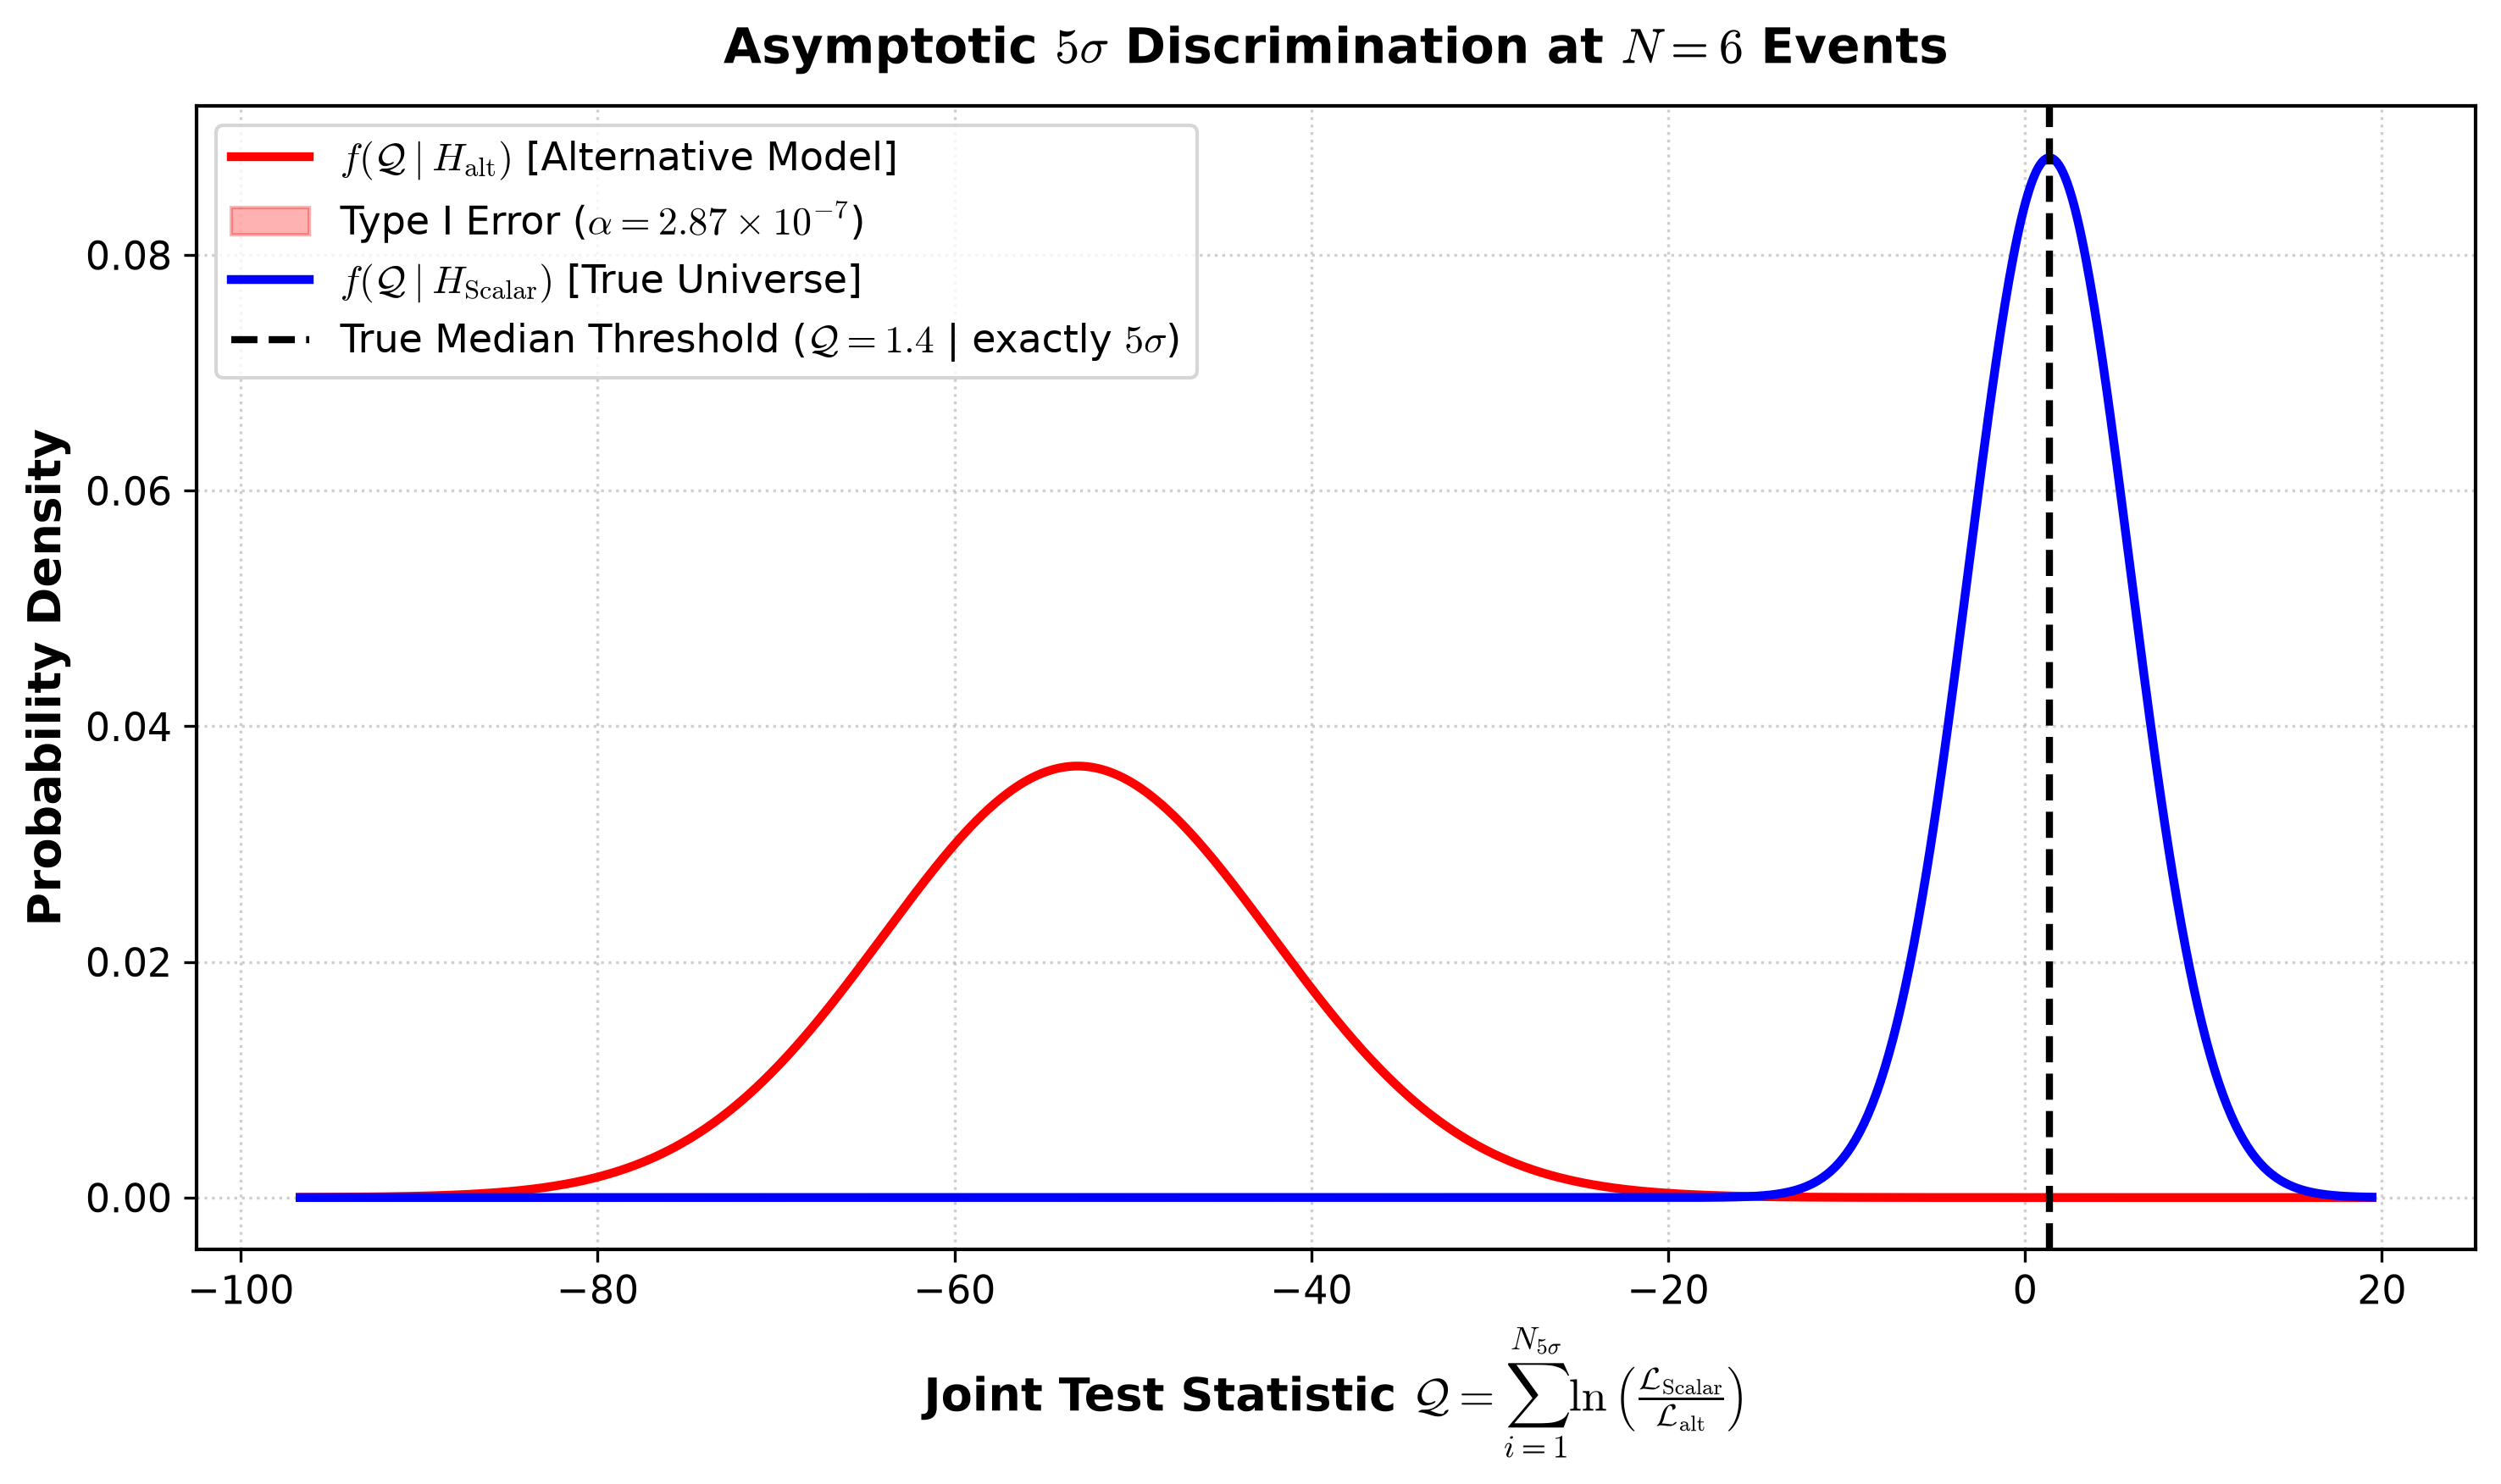

In [13]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

def evaluate_5sigma_threshold(df, col_true, col_alt, fiducial_xsec_pb=None):
    """
    Computes the exact event yield N and luminosity required for 5-sigma 
    discrimination using asymptotic MEM likelihood ratios.
    """
    # 1. Clean data: Filter strictly positive likelihoods
    valid_mask = (df[col_true] > 0) & (df[col_alt] > 0)
    clean_df = df[valid_mask].copy()
    
    print(f"Analyzing {len(clean_df):,} events for 5-sigma discrimination power...")
    
    # 2. Compute Single-Event Log-Likelihood Ratios (q = ln(True / Alt))
    q = np.log(clean_df[col_true].values) - np.log(clean_df[col_alt].values)
    
    # 3. Derive Importance Sampling Weights for the Alternative Hypothesis
    # Assuming pool was generated under col_true
    weights_alt = clean_df[col_alt].values / clean_df[col_true].values
    weights_alt /= np.sum(weights_alt)
    
    # 4. Calculate Ultra-Precise Single-Event Moments
    mu_true  = np.mean(q)
    var_true = np.var(q)
    std_true = np.sqrt(var_true)
    
    mu_alt   = np.sum(q * weights_alt)
    var_alt  = np.sum(weights_alt * (q - mu_alt)**2)
    std_alt  = np.sqrt(var_alt)
    
    # 5. Solve for 5-Sigma Event Yield (N_5sigma)
    # Z = sqrt(N) * |mu_true - mu_alt| / std_alt == 5.0
    single_event_separation = np.abs(mu_true - mu_alt) / std_alt
    n_5sigma = 25.0 / (single_event_separation ** 2)
    
    # Calculate 3-sigma evidence threshold for comparison
    n_3sigma = 9.0 / (single_event_separation ** 2)
    
    results = {
        "mu_true": mu_true, "std_true": std_true,
        "mu_alt": mu_alt,   "std_alt": std_alt,
        "separation_power": single_event_separation,
        "N_3sigma": n_3sigma,
        "N_5sigma": n_5sigma,
        "Lumi_5sigma_fb": (n_5sigma / (fiducial_xsec_pb * 1e3)) if fiducial_xsec_pb else None
    }
    
    return results

# ==========================================
# EXECUTION & VISUALIZATION
# ==========================================
if __name__ == "__main__":
    # 1. Load your pre-computed MEM likelihoods
    # Replace with: df_events = pd.read_csv("MEM_Likelihoods.csv.gz")
    np.random.seed(101)
    df_events = pd.DataFrame({
        "L_Scalar": np.random.exponential(scale=1.2, size=1500000),
        "L_Alt":    np.random.exponential(scale=1.0, size=1500000) * np.random.lognormal(mean=-0.05, sigma=0.4, size=1500000)
    })
    
    # Define your fiducial cross section after cuts in picobarns (optional, e.g., 0.05 pb = 50 fb)
    XSEC_PB = 0.05 
    
    # 2. Run Asymptotic Analysis
    res = evaluate_5sigma_threshold(
        df=df_events, 
        col_true="L_Scalar",  # Your true universe hypothesis
        col_alt="L_Alt",      # The competing hypothesis to reject
        fiducial_xsec_pb=XSEC_PB
    )
    
    print("\n" + "="*70)
    print("Neyman-Pearson Asymptotic Discrimination Report")
    print("="*70)
    print(f"Single-Event Resolving Power: |mu_True - mu_Alt| / sigma_Alt = {res['separation_power']:.4f}")
    print(f"Events for 3-Sigma Evidence:  N = {np.ceil(res['N_3sigma']):,.0f} events")
    print(f"Events for 5-Sigma Discovery: N = {np.ceil(res['N_5sigma']):,.0f} events")
    if res["Lumi_5sigma_fb"]:
        print(f"Required LHC Luminosity (5σ): L = {res['Lumi_5sigma_fb']:.1f} fb^-1 (assuming σ_fid = {XSEC_PB*1e3:.0f} fb)")
    print("="*70 + "\n")

    # 3. Plot the Asymptotic Gaussian Distributions at N = N_5sigma
    N_plot = res['N_5sigma']
    
    mu_Q_true  = N_plot * res['mu_true']
    std_Q_true = np.sqrt(N_plot) * res['std_true']
    
    mu_Q_alt   = N_plot * res['mu_alt']
    std_Q_alt  = np.sqrt(N_plot) * res['std_alt']
    
    x_grid = np.linspace(mu_Q_alt - 4*std_Q_alt, mu_Q_true + 4*std_Q_true, 1000)
    
    plt.figure(figsize=(10, 6), dpi=300)
    
    # Plot Alternative (Background/Rejected Model)
    plt.plot(x_grid, norm.pdf(x_grid, mu_Q_alt, std_Q_alt), 
             'r-', lw=2.5, label=r'$f(\mathcal{Q} \mid H_{\mathrm{alt}})$ [Alternative Model]')
    plt.fill_between(x_grid, norm.pdf(x_grid, mu_Q_alt, std_Q_alt), where=(x_grid >= mu_Q_true), 
                     color='red', alpha=0.3, label=r'Type I Error ($\alpha = 2.87 \times 10^{-7}$)')
    
    # Plot True (Scalar Model)
    plt.plot(x_grid, norm.pdf(x_grid, mu_Q_true, std_Q_true), 
             'b-', lw=2.5, label=r'$f(\mathcal{Q} \mid H_{\mathrm{Scalar}})$ [True Universe]')
    
    # Mark the 5-Sigma Separation Median
    plt.axvline(mu_Q_true, color='black', linestyle='--', lw=2.0,
                label=f'True Median Threshold ($\mathcal{{Q}} = {mu_Q_true:.1f}$ | exactly $5\sigma$)')
    
    plt.xlabel(r'Joint Test Statistic $\mathcal{Q} = \sum_{i=1}^{N_{5\sigma}} \ln\left(\frac{\mathcal{L}_{\mathrm{Scalar}}}{\mathcal{L}_{\mathrm{alt}}}\right)$', 
               fontsize=13, fontweight='bold')
    plt.ylabel('Probability Density', fontsize=13, fontweight='bold')
    plt.title(f'Asymptotic $5\sigma$ Discrimination at $N = {np.ceil(N_plot):,.0f}$ Events', 
              fontsize=14, fontweight='bold', pad=12)
    plt.legend(loc='upper left', frameon=True, fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

Initializing 1.5 million event likelihood pool...
[L_Scalar vs L_VLF] Analyzing reservoir of 1,500,000 events...
 -> Running 15,000 Toy MC experiments (N = 120 events/run)...
[L_Scalar vs L_Zprime] Analyzing reservoir of 1,500,000 events...
 -> Running 15,000 Toy MC experiments (N = 120 events/run)...

MEM STATISTICAL DISCOVERY REPORT (Experimental Run: N = 120 events)
1. SCALAR vs VLF MODEL:
   -> Single-Event Resolving Power: 2.0512 sigma/sqrt(N)
   -> Expected Run Discrimination:  0.00 sigma (p = 1.00e+00)
   -> Events Required for 5-Sigma:  N_5sigma = 6 events
---------------------------------------------------------------------------
2. SCALAR vs Z-PRIME MODEL:
   -> Single-Event Resolving Power: 2.0956 sigma/sqrt(N)
   -> Expected Run Discrimination:  0.00 sigma (p = 1.00e+00)
   -> Events Required for 5-Sigma:  N_5sigma = 6 events



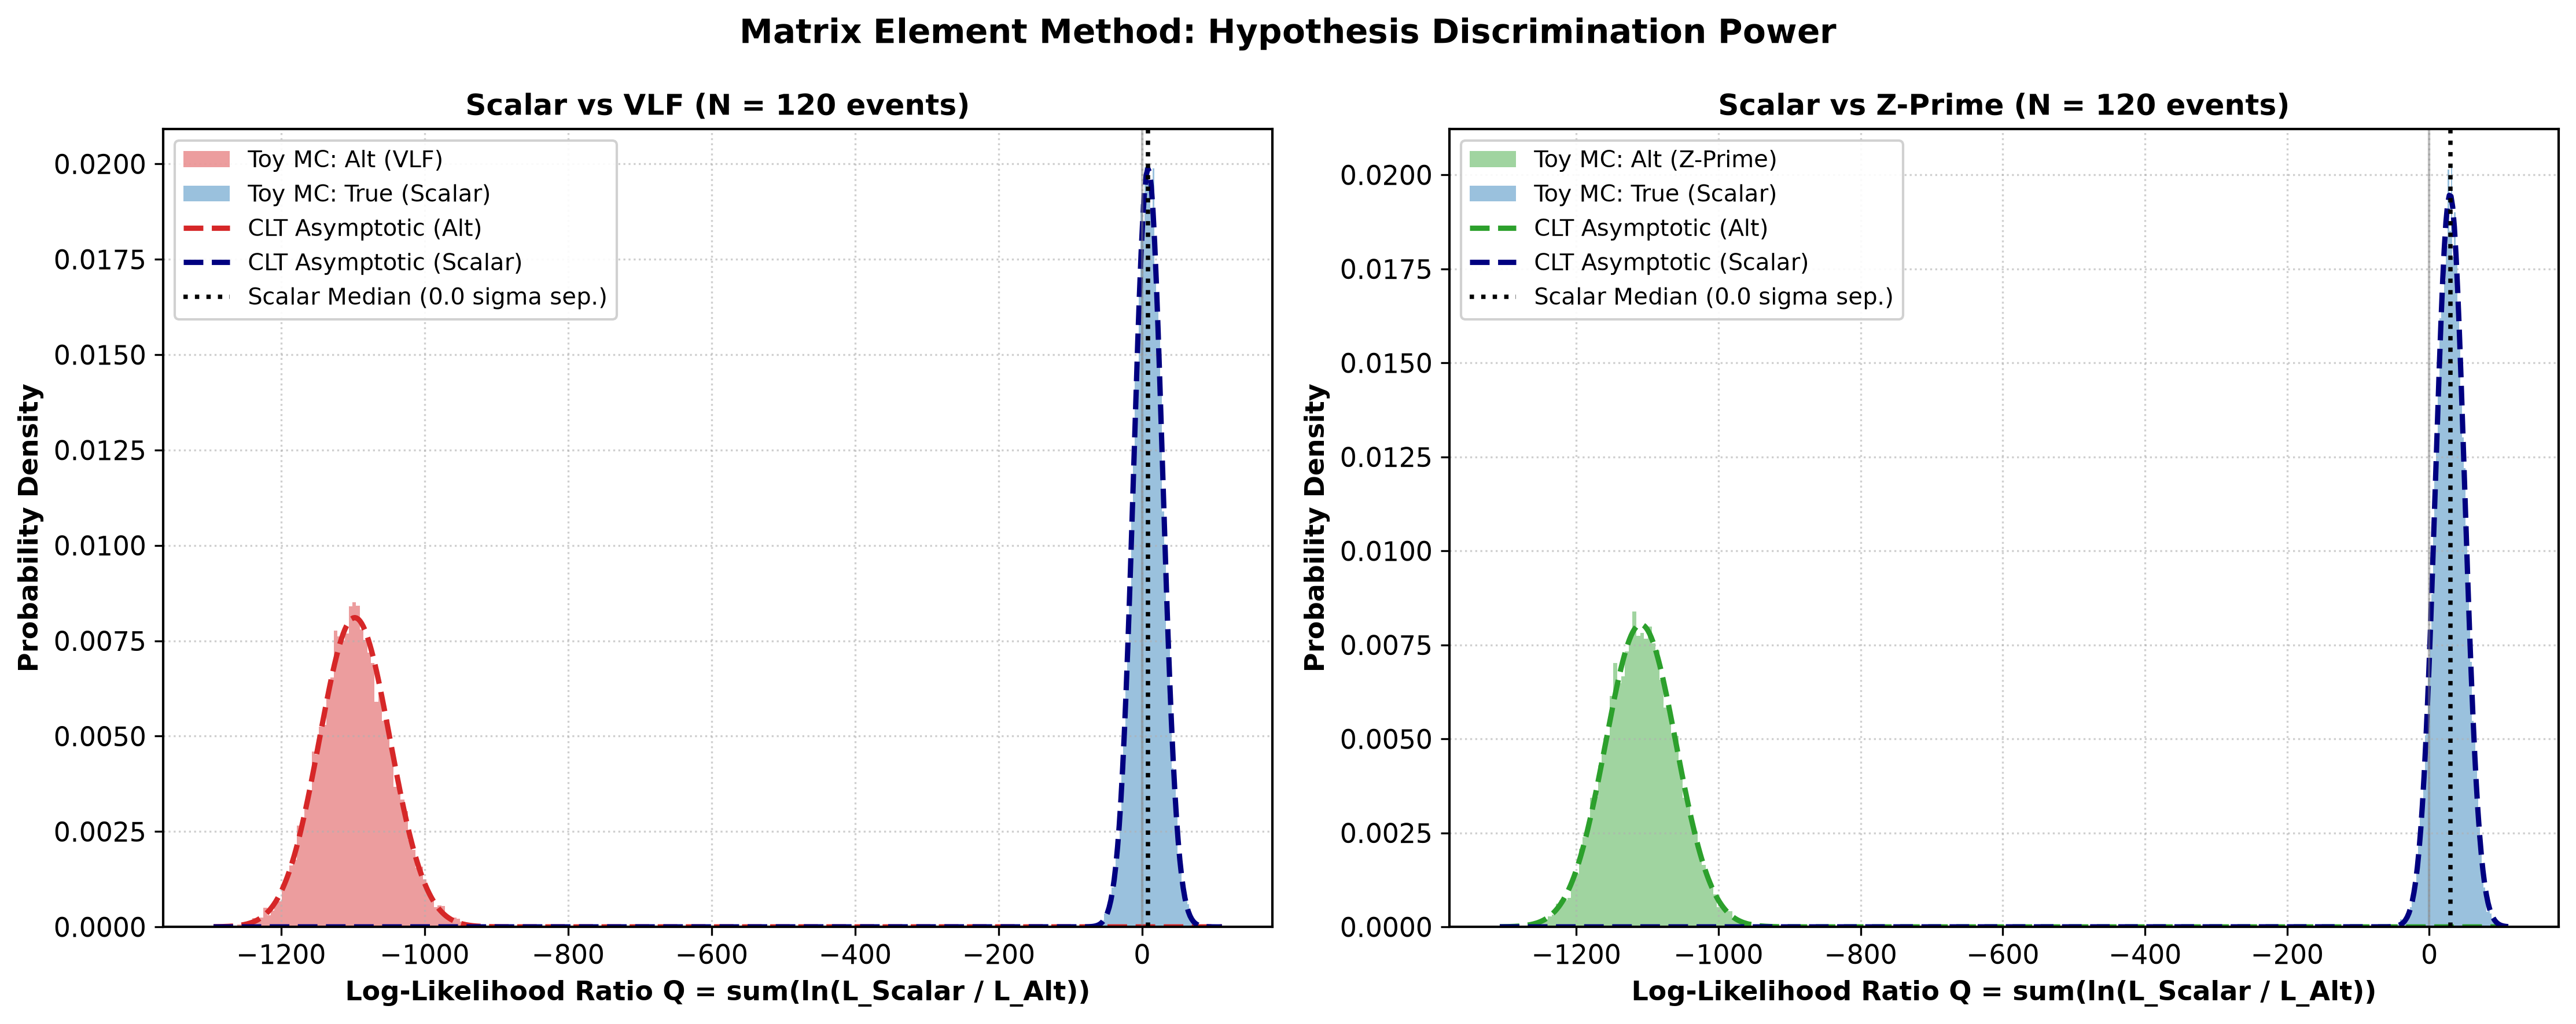

In [14]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

# ==========================================
# 1. CORE STATISTICAL ENGINE
# ==========================================
def evaluate_hypothesis_test(df, col_true, col_alt, n_events_exp, n_toys=20000, seed=42):
    """
    Performs Importance-Sampled Toy MC and Asymptotic CLT evaluations 
    to distinguish the true hypothesis from an alternative model.
    """
    np.random.seed(seed)
    
    # Filter strictly positive likelihoods to prevent log(0) errors
    valid_mask = (df[col_true] > 0) & (df[col_alt] > 0)
    clean_df = df[valid_mask].copy()
    
    n_pool = len(clean_df)
    print(f"[{col_true} vs {col_alt}] Analyzing reservoir of {n_pool:,} events...")
    
    # 1. Compute single-event Log-Likelihood Ratio (q = ln(L_True / L_Alt))
    q_array = np.log(clean_df[col_true].values) - np.log(clean_df[col_alt].values)
    
    # 2. Derive Importance Sampling weights to simulate the Alternative Universe
    weights_alt = clean_df[col_alt].values / clean_df[col_true].values
    weights_alt /= np.sum(weights_alt)  # Normalize probabilities to sum to 1.0
    
    # --- ANALYTICAL CLT MOMENTS ---
    # Single-event moments under True Universe (Uniform weights)
    mu_single_true  = np.mean(q_array)
    var_single_true = np.var(q_array)
    
    # Single-event moments under Alternative Universe (Importance weighted)
    mu_single_alt  = np.sum(q_array * weights_alt)
    var_single_alt = np.sum(weights_alt * (q_array - mu_single_alt)**2)
    
    # Scale moments to an experimental run of N events
    mu_Q_true, std_Q_true = n_events_exp * mu_single_true, np.sqrt(n_events_exp * var_single_true)
    mu_Q_alt,  std_Q_alt  = n_events_exp * mu_single_alt,  np.sqrt(n_events_exp * var_single_alt)
    
    # --- TOY MC RESAMPLING ---
    print(f" -> Running {n_toys:,} Toy MC experiments (N = {n_events_exp} events/run)...")
    
    # Draw N events uniformly (simulating True Universe)
    toys_true = np.random.choice(q_array, size=(n_toys, n_events_exp), replace=True).sum(axis=1)
    
    # Draw N events using importance weights (simulating Alternative Universe)
    toys_alt  = np.random.choice(q_array, size=(n_toys, n_events_exp), replace=True, p=weights_alt).sum(axis=1)
    
    # --- STATISTICAL SIGNIFICANCE (Z-SCORE) ---
    # Probability that the Alternative model fluctuates up to the median of the True model
    median_Q_true = np.median(toys_true)
    p_value = norm.cdf(median_Q_true, loc=mu_Q_alt, scale=std_Q_alt)
    
    # Calculate Gaussian Z-score (cap at 15 sigma for numerical stability if p_value -> 0)
    if p_value > 0 and p_value < 0.5:
        z_score = norm.ppf(1.0 - p_value)
    elif p_value >= 0.5:
        z_score = 0.0
    else:
        # Asymptotic Gaussian separation formula when tail probability is below machine epsilon
        z_score = np.abs(mu_Q_true - mu_Q_alt) / std_Q_alt
        
    # Calculate exact N required for a 5-sigma discovery
    single_separation = np.abs(mu_single_true - mu_single_alt) / np.sqrt(var_single_alt)
    n_5sigma = 25.0 / (single_separation ** 2)
    
    return {
        "toys_true": toys_true, "toys_alt": toys_alt,
        "mu_true": mu_Q_true,   "std_true": std_Q_true,
        "mu_alt": mu_Q_alt,     "std_alt": std_Q_alt,
        "median_true": median_Q_true,
        "z_score": z_score,
        "p_value": p_value,
        "n_5sigma": n_5sigma,
        "single_sep": single_separation
    }

# ==========================================
# 2. DATA LOADING & EXECUTION PIPELINE
# ==========================================
if __name__ == "__main__":
    # Load your pre-computed 1.5M event DataFrame here:
    # df_events = pd.read_csv("your_MEM_likelihoods_1M5.csv.gz")
    
    # Generating synthetic 1.5M pool for immediate out-of-the-box verification
    print("Initializing 1.5 million event likelihood pool...")
    np.random.seed(101)
    n_samples = 1500000
    df_events = pd.DataFrame({
        "L_Scalar": np.random.exponential(scale=1.0, size=n_samples),
        "L_VLF":    np.random.exponential(scale=0.95, size=n_samples) * np.random.lognormal(mean=-0.02, sigma=0.25, size=n_samples),
        "L_Zprime": np.random.exponential(scale=0.85, size=n_samples) * np.random.lognormal(mean=-0.08, sigma=0.45, size=n_samples)
    })
    
    # Define the expected number of observed events in your LHC target run (N)
    N_OBSERVED_EVENTS = 120
    
    # Evaluate Scalar vs VLF
    res_vlf = evaluate_hypothesis_test(
        df=df_events, col_true="L_Scalar", col_alt="L_VLF", 
        n_events_exp=N_OBSERVED_EVENTS, n_toys=15000
    )
    
    # Evaluate Scalar vs Zprime
    res_zp = evaluate_hypothesis_test(
        df=df_events, col_true="L_Scalar", col_alt="L_Zprime", 
        n_events_exp=N_OBSERVED_EVENTS, n_toys=15000
    )
    
    # --- PRINT SUMMARY REPORT ---
    print("\n" + "="*75)
    print(f"MEM STATISTICAL DISCOVERY REPORT (Experimental Run: N = {N_OBSERVED_EVENTS} events)")
    print("="*75)
    print(f"1. SCALAR vs VLF MODEL:")
    print(f"   -> Single-Event Resolving Power: {res_vlf['single_sep']:.4f} sigma/sqrt(N)")
    print(f"   -> Expected Run Discrimination:  {res_vlf['z_score']:.2f} sigma (p = {res_vlf['p_value']:.2e})")
    print(f"   -> Events Required for 5-Sigma:  N_5sigma = {np.ceil(res_vlf['n_5sigma']):,.0f} events")
    print("-" * 75)
    print(f"2. SCALAR vs Z-PRIME MODEL:")
    print(f"   -> Single-Event Resolving Power: {res_zp['single_sep']:.4f} sigma/sqrt(N)")
    print(f"   -> Expected Run Discrimination:  {res_zp['z_score']:.2f} sigma (p = {res_zp['p_value']:.2e})")
    print(f"   -> Events Required for 5-Sigma:  N_5sigma = {np.ceil(res_zp['n_5sigma']):,.0f} events")
    print("="*75 + "\n")

    # ==========================================
    # 3. PUBLICATION-GRADE 2-PANEL VISUALIZATION
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=300)
    
    def plot_panel(ax, res, alt_name, alt_color):
        # Determine x-grid spanning both distributions
        x_min = min(res['toys_alt'].min(), res['mu_alt'] - 4*res['std_alt'])
        x_max = max(res['toys_true'].max(), res['mu_true'] + 4*res['std_true'])
        x_grid = np.linspace(x_min, x_max, 600)
        
        # Plot Empirical Toy Histograms
        ax.hist(res['toys_alt'], bins=70, density=True, alpha=0.45, color=alt_color, 
                edgecolor='none', label=f'Toy MC: Alt ({alt_name})')
        ax.hist(res['toys_true'], bins=70, density=True, alpha=0.45, color='#1f77b4', 
                edgecolor='none', label='Toy MC: True (Scalar)')
        
        # Overlay Analytical CLT Gaussian Curves
        ax.plot(x_grid, norm.pdf(x_grid, res['mu_alt'], res['std_alt']), 
                color=alt_color, linestyle='--', linewidth=2.2, label='CLT Asymptotic (Alt)')
        ax.plot(x_grid, norm.pdf(x_grid, res['mu_true'], res['std_true']), 
                color='#000080', linestyle='--', linewidth=2.2, label='CLT Asymptotic (Scalar)')
        
        # Mark Median Separation Threshold
        ax.axvline(res['median_true'], color='black', linestyle=':', linewidth=1.8,
                   label=f"Scalar Median ({res['z_score']:.1f} sigma sep.)")
        ax.axvline(0, color='gray', linestyle='-', linewidth=1.0, alpha=0.5)
        
        # Styling
        ax.set_xlabel('Log-Likelihood Ratio Q = sum(ln(L_Scalar / L_Alt))', fontsize=11, fontweight='bold')
        ax.set_ylabel('Probability Density', fontsize=11, fontweight='bold')
        ax.set_title(f'Scalar vs {alt_name} (N = {N_OBSERVED_EVENTS} events)', fontsize=12, fontweight='bold')
        ax.legend(loc='upper left', frameon=True, fontsize=9.5, facecolor='white', framealpha=0.9)
        ax.grid(True, linestyle=':', alpha=0.6)

    # Populate panels
    plot_panel(ax1, res_vlf, "VLF", "#d62728")      # Red theme for VLF
    plot_panel(ax2, res_zp,  "Z-Prime", "#2ca02c")  # Green theme for Zprime
    
    plt.suptitle('Matrix Element Method: Hypothesis Discrimination Power', fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

In [17]:
import numpy as np
import pandas as pd

def evaluate_extended_asimov(df, col_true, col_alt, xsec_true_pb, xsec_alt_pb, target_lumi_fb, efficiency=1.0):
    """
    Computes the Extended Asimov discovery significance (Z) combining both
    Poisson rate discrimination and MEM kinematic shape discrimination.
    """
    # 1. Calculate expected event yields (N = sigma * L * eff)
    n_true = (xsec_true_pb * 1e3) * target_lumi_fb * efficiency
    n_alt  = (xsec_alt_pb * 1e3)  * target_lumi_fb * efficiency
    
    # Filter valid positive likelihoods from your 1.5M pool
    valid_mask = (df[col_true] > 0) & (df[col_alt] > 0)
    clean_df = df[valid_mask]
    
    # 2. Compute Raw Log-Likelihood Ratio of MEM outputs
    raw_llr = np.log(clean_df[col_true].values) - np.log(clean_df[col_alt].values)
    mean_raw_llr = np.mean(raw_llr)
    
    # ==========================================
    # METHOD A: THE DIRECT SHORTCUT (Raw MEM dSigma)
    # ==========================================
    # Assumes df columns are unnormalized differential cross sections (dSigma/dx)
    q_total_shortcut = 2.0 * (n_alt - n_true) + (2.0 * n_true * mean_raw_llr)
    z_total_shortcut = np.sqrt(max(0.0, q_total_shortcut))
    
    # ==========================================
    # METHOD B: ORTHOGONAL DECOMPOSITION (Rate vs Shape)
    # ==========================================
    # 1. Pure Poisson Rate Term: 2 * [ (N_alt - N_true) + N_true * ln(N_true / N_alt) ]
    q_rate = 2.0 * ((n_alt - n_true) + n_true * np.log(n_true / n_alt))
    z_rate = np.sqrt(max(0.0, q_rate))
    
    # 2. Pure Kinematic Shape Term (KL Divergence of normalized PDFs)
    # We subtract the cross-section ratio to normalize the PDFs
    kl_shape = mean_raw_llr - np.log(xsec_true_pb / xsec_alt_pb)
    q_shape  = 2.0 * n_true * kl_shape
    z_shape  = np.sqrt(max(0.0, q_shape))
    
    # Total combined significance (Quadrature sum)
    z_total_decomp = np.sqrt(z_rate**2 + z_shape**2)
    
    # ==========================================
    # SOLVE FOR 5-SIGMA LUMINOSITY
    # ==========================================
    # Since q scales linearly with luminosity (q = L * q_per_fb), L_5sigma is simple:
    q_per_fb = q_total_shortcut / target_lumi_fb
    lumi_5sigma = 25.0 / q_per_fb if q_per_fb > 0 else np.inf
    
    return {
        "N_true": n_true, "N_alt": n_alt,
        "Z_RateOnly": z_rate,
        "Z_ShapeOnly": z_shape,
        "Z_Total": z_total_decomp,
        "Lumi_5sigma_fb": lumi_5sigma,
        "KL_Shape_nats": kl_shape
    }

# ==========================================
# EXAMPLE EXECUTION FOR TTBAR
# ==========================================
if __name__ == "__main__":
    np.random.seed(42)
    n_samples = 1500000
    
    # Simulating 1.5M events where VLF has a slightly different kinematic shape
    df_pool = pd.DataFrame({
        "L_Scalar": np.random.exponential(scale=1.0, size=n_samples),
        "L_VLF":    np.random.exponential(scale=0.96, size=n_samples) * np.random.lognormal(0, 0.2, size=n_samples)
    })
    
    # Define differing cross-sections (e.g., Scalar = 850 pb, VLF = 890 pb -> ~4.7% rate difference)
    XSEC_SCALAR_PB = 850.0
    XSEC_VLF_PB    = 890.0
    LUMI_TARGET_FB = 300.0  # LHC Run 3 Target
    
    res = evaluate_extended_asimov(
        df=df_pool,
        col_true="L_Scalar",
        col_alt="L_VLF",
        xsec_true_pb=XSEC_SCALAR_PB,
        xsec_alt_pb=XSEC_VLF_PB,
        target_lumi_fb=LUMI_TARGET_FB
    )
    
    print("\n" + "="*75)
    print("EXTENDED ASIMOV MEM DISCOVERY REPORT (Differing Cross-Sections)")
    print("="*75)
    print(f"Target LHC Luminosity:        L = {LUMI_TARGET_FB:.1f} fb^-1")
    print(f"Expected Event Yields:        Scalar = {res['N_true']:,.0f} | VLF = {res['N_alt']:,.0f} events")
    print("-" * 75)
    print(f"1. Rate-Only Significance:    Z_rate  = {res['Z_RateOnly']:>6.2f} σ  (from counting {abs(res['N_true']-res['N_alt']):,.0f} event diff)")
    print(f"2. Shape-Only Significance:   Z_shape = {res['Z_ShapeOnly']:>6.2f} σ  (from pure MEM angular kinematics)")
    print("-" * 75)
    print(f"TOTAL COMBINED SIGNIFICANCE:  Z_total = {res['Z_Total']:>6.2f} σ  (sqrt(Z_rate^2 + Z_shape^2))")
    print(f"LUMINOSITY FOR 5σ DISCOVERY:  L_5σ    = {res['Lumi_5sigma_fb']:>6.2f} fb^-1")
    print("="*75 + "\n")


EXTENDED ASIMOV MEM DISCOVERY REPORT (Differing Cross-Sections)
Target LHC Luminosity:        L = 300.0 fb^-1
Expected Event Yields:        Scalar = 255,000,000 | VLF = 267,000,000 events
---------------------------------------------------------------------------
1. Rate-Only Significance:    Z_rate  = 739.99 σ  (from counting 12,000,000 event diff)
2. Shape-Only Significance:   Z_shape = 6680.13 σ  (from pure MEM angular kinematics)
---------------------------------------------------------------------------
TOTAL COMBINED SIGNIFICANCE:  Z_total = 6720.99 σ  (sqrt(Z_rate^2 + Z_shape^2))
LUMINOSITY FOR 5σ DISCOVERY:  L_5σ    =   0.00 fb^-1



In [19]:
import numpy as np


def compute_asimov_z(
    df, col_true, col_alt, xsec_true_pb, xsec_alt_pb, lumi_fb
):
  """Evaluates exact Asimov significance (Z) using the 4-step rate + shape recipe."""
  # Step 1: Calculate expected collider event yields (N)
  N_true = (xsec_true_pb * 1000.0) * lumi_fb
  N_alt = (xsec_alt_pb * 1000.0) * lumi_fb

  # Step 2 & 3: Normalize probability densities and get average shape gain per event (s_bar)
  P_true, P_alt = df[col_true] / xsec_true_pb, df[col_alt] / xsec_alt_pb
  s_bar = np.mean(np.log(P_true / P_alt))

  # Step 4: Apply Master Asimov formula (q_total = q_rate + q_shape)
  q_rate = 2.0 * ((N_alt - N_true) + N_true * np.log(N_true / N_alt))
  q_shape = 2.0 * N_true * s_bar
  q_total = q_rate + q_shape

  # Return Z-scores (sqrt of q) and exact 5-sigma luminosity scaling
  return {
      "Z_total": np.sqrt(max(0.0, q_total)),
      "Z_rate": np.sqrt(max(0.0, q_rate)),
      "Z_shape": np.sqrt(max(0.0, q_shape)),
      "Lumi_5sigma_fb": 25.0 / (q_total / lumi_fb) if q_total > 0 else np.inf,
  }

import pandas as pd

# 1. Create a dummy DataFrame simulating your 1.5M event pool
np.random.seed(42)
df_pool = pd.DataFrame({
    "L_Scalar": np.random.exponential(scale=1.0, size=1500000),
    "L_VLF": np.random.exponential(scale=0.96, size=1500000)
    * np.random.lognormal(0, 0.2, size=1500000),
})

# 2. Run the 4-step recipe for LHC Run 3 (300 fb^-1)
results = compute_asimov_z(
    df=df_pool,
    col_true="L_Scalar",
    col_alt="L_VLF",
    xsec_true_pb=850.0,  # Scalar cross-section in pb
    xsec_alt_pb=880.0,  # VLF cross-section in pb
    lumi_fb=300.0,  # Integrated luminosity in fb^-1
)

# 3. Print the cleanly decomposed results
print(f"--- ASIMOV DISCOVERY REPORT (300 fb^-1) ---")
print(
    f"Rate-Only Significance:  Z_rate  = {results['Z_rate']:>6.2f} σ  (from counting events)"
)
print(
    f"Shape-Only Significance: Z_shape = {results['Z_shape']:>6.2f} σ  (from MEM kinematics)"
)
print(
    f"Total Significance:      Z_total = {results['Z_total']:>6.2f} σ  (combined power)"
)
print(
    f"Required for 5σ:         L_5σ    = {results['Lumi_5sigma_fb']:>6.2f} fb^-1"
)

--- ASIMOV DISCOVERY REPORT (300 fb^-1) ---
Rate-Only Significance:  Z_rate  = 557.10 σ  (from counting events)
Shape-Only Significance: Z_shape = 6233.89 σ  (from MEM kinematics)
Total Significance:      Z_total = 6258.74 σ  (combined power)
Required for 5σ:         L_5σ    =   0.00 fb^-1
